# ML-Powered RSI Trading System

**Goal**: Replace walk-forward RSI optimization with ML models

**Two Approaches to Compare**:
1. **Method A: Direct Signal Generator** - ML predicts BUY/SELL/HOLD directly
2. **Method B: Dynamic Threshold Generator** - ML predicts optimal RSI entry/exit bounds

**Features**:
- Full risk management (TP/SL, position sizing)
- Comprehensive backtesting
- Side-by-side performance comparison
- Beautiful visualizations (price, signals, equity)

**Inputs**: Close, RSI_14, Volume, OHLCV data

## Part 1: Setup

### 1.1 Import Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Technical analysis
import talib

# Custom modules
from Data_Handling import get_data_auto

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

print("✓ Libraries imported successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")
print(f"🔢 TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
📅 Analysis Date: 2026-01-20
🔢 TensorFlow version: 2.20.0


### 1.2 Configuration

In [76]:
# Data parameters
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1

# Time periods
TRAIN_START = "2018-01-01"
TRAIN_END = "2024-09-30"
TEST_START = "2024-10-01"
TEST_END = "2025-12-31"

# Model configuration
LOOKBACK_WINDOW = 60  # Days of history to look at
RSI_PERIOD = 14
LSTM_UNITS = 64
NUM_LAYERS = 2
DROPOUT = 0.3
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Risk management
INITIAL_CAPITAL = 10000
POSITION_SIZE_PCT = 1.0  # 100% or fractional (0.1 = 10%)
TAKE_PROFIT_PCT = 0.03  # 3% TP
STOP_LOSS_PCT = 0.015   # 1.5% SL
USE_RISK_MANAGEMENT = True

print("="*80)
print("ML RSI TRADING SYSTEM CONFIGURATION")
print("="*80)
print(f"\n📊 Data:")
print(f"   Symbol: {SYMBOL}")
print(f"   Training: {TRAIN_START} → {TRAIN_END}")
print(f"   Testing: {TEST_START} → {TEST_END}")
print(f"\n🤖 Models:")
print(f"   Method A: Direct Signal Classifier (BUY/HOLD/SELL)")
print(f"   Method B: Dynamic RSI Threshold Predictor")
print(f"\n🏗️  Architecture:")
print(f"   Lookback: {LOOKBACK_WINDOW} days")
print(f"   LSTM: {NUM_LAYERS} layers × {LSTM_UNITS} units")
print(f"   RSI Period: {RSI_PERIOD}")
print(f"\n💰 Risk Management:")
print(f"   Initial Capital: ${INITIAL_CAPITAL:,.0f}")
print(f"   Position Size: {POSITION_SIZE_PCT*100:.0f}%")
print(f"   Take Profit: {TAKE_PROFIT_PCT*100:.1f}%")
print(f"   Stop Loss: {STOP_LOSS_PCT*100:.1f}%")
print(f"   Enabled: {USE_RISK_MANAGEMENT}")
print("="*80)

ML RSI TRADING SYSTEM CONFIGURATION

📊 Data:
   Symbol: SPY
   Training: 2018-01-01 → 2024-09-30
   Testing: 2024-10-01 → 2025-12-31

🤖 Models:
   Method A: Direct Signal Classifier (BUY/HOLD/SELL)
   Method B: Dynamic RSI Threshold Predictor

🏗️  Architecture:
   Lookback: 60 days
   LSTM: 2 layers × 64 units
   RSI Period: 14

💰 Risk Management:
   Initial Capital: $10,000
   Position Size: 100%
   Take Profit: 3.0%
   Stop Loss: 1.5%
   Enabled: True


## Part 2: Load & Prepare Data

In [77]:
print("Loading training data...")
train_data = get_data_auto(
    symbol=SYMBOL,
    start=TRAIN_START,
    end=TRAIN_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("Loading test data...")
test_data = get_data_auto(
    symbol=SYMBOL,
    start=TEST_START,
    end=TEST_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("\n" + "="*80)
print("DATA LOADED")
print("="*80)
print(f"\n📈 Training: {len(train_data)} days ({train_data.index[0].date()} → {train_data.index[-1].date()})")
print(f"📊 Testing: {len(test_data)} days ({test_data.index[0].date()} → {test_data.index[-1].date()})")
print(f"\n🔢 Columns: {list(train_data.columns)}")
print("="*80)

Loading training data...
Loading test data...

DATA LOADED

📈 Training: 1696 days (2018-01-02 → 2024-09-27)
📊 Testing: 313 days (2024-10-01 → 2025-12-30)

🔢 Columns: ['Open', 'High', 'Low', 'Close', 'Volume']


### 2.1 Feature Engineering

In [78]:
def calculate_features(data):
    """
    Calculate comprehensive features for ML models.
    
    Features:
    - Price returns (OHLCV)
    - RSI (14-period)
    - Volume indicators
    - Price momentum
    - Volatility
    """
    df = data.copy()
    
    # Price returns
    for col in ['Open', 'High', 'Low', 'Close']:
        df[f'{col}_return'] = df[col].pct_change().fillna(0)
    
    # Volume return
    df['Volume_return'] = df['Volume'].pct_change().fillna(0)
    
    # RSI
    df['RSI'] = talib.RSI(df['Close'].values, timeperiod=RSI_PERIOD)
    df['RSI'] = df['RSI'].fillna(50) / 100.0  # Normalize to 0-1
    
    # Rolling statistics
    df['volatility_20'] = df['Close_return'].rolling(window=20, min_periods=1).std().fillna(0)
    df['momentum_10'] = df['Close'].pct_change(10).fillna(0)
    df['volume_ma_ratio'] = (df['Volume'] / df['Volume'].rolling(window=20, min_periods=1).mean()).fillna(1)
    
    # Price position (where is price relative to recent range)
    high_20 = df['High'].rolling(window=20, min_periods=1).max()
    low_20 = df['Low'].rolling(window=20, min_periods=1).min()
    df['price_position'] = ((df['Close'] - low_20) / (high_20 - low_20)).fillna(0.5)
    
    return df

# Apply feature engineering
train_features = calculate_features(train_data)
test_features = calculate_features(test_data)

print("✓ Features calculated")
print(f"\n📊 Feature columns ({len(train_features.columns)} total):")
for col in train_features.columns:
    print(f"   - {col}")

# Show sample
print("\n📈 Sample data (first 5 rows):")
display_cols = ['Close', 'RSI', 'volatility_20', 'momentum_10', 'price_position']
print(train_features[display_cols].head().to_string())

✓ Features calculated

📊 Feature columns (15 total):
   - Open
   - High
   - Low
   - Close
   - Volume
   - Open_return
   - High_return
   - Low_return
   - Close_return
   - Volume_return
   - RSI
   - volatility_20
   - momentum_10
   - volume_ma_ratio
   - price_position

📈 Sample data (first 5 rows):
field                           Close  RSI  volatility_20  momentum_10  price_position
timestamp                                                                             
2018-01-02 05:00:00+00:00  237.208237  0.5       0.000000          0.0        0.971625
2018-01-03 05:00:00+00:00  238.708679  0.5       0.004473          0.0        0.947528
2018-01-04 05:00:00+00:00  239.714722  0.5       0.003220          0.0        0.884450
2018-01-05 05:00:00+00:00  241.312180  0.5       0.003065          0.0        0.977275
2018-01-08 05:00:00+00:00  241.753479  0.5       0.002876          0.0        0.973135


### 2.2 Create Labels for Method A (Direct Signals)

Labels: BUY (0), HOLD (1), SELL (2)
- BUY: When future return > threshold
- SELL: When future return < -threshold
- HOLD: Otherwise

In [79]:
def create_signal_labels(data, horizon=1, threshold=0.005):
    """
    Create BUY/HOLD/SELL labels based on future returns.
    
    Parameters:
    -----------
    data : pd.DataFrame
        Feature data with 'Close' column
    horizon : int
        Days ahead to look for returns
    threshold : float
        Return threshold for BUY/SELL (default 0.5%)
        
    Returns:
    --------
    labels : np.ndarray
        0 = BUY, 1 = HOLD, 2 = SELL
    """
    future_returns = data['Close'].pct_change(horizon).shift(-horizon)
    
    labels = np.where(future_returns > threshold, 0,      # BUY
             np.where(future_returns < -threshold, 2,     # SELL
                      1))                                 # HOLD
    
    return labels

# Create labels
train_features['signal_label'] = create_signal_labels(train_features, horizon=1, threshold=0.005)
test_features['signal_label'] = create_signal_labels(test_features, horizon=1, threshold=0.005)

# Check distribution
print("Signal Label Distribution (Training):")
label_counts = pd.Series(train_features['signal_label']).value_counts().sort_index()
label_names = {0: 'BUY', 1: 'HOLD', 2: 'SELL'}
for label, count in label_counts.items():
    pct = (count / len(train_features)) * 100
    print(f"   {label_names[label]:4s}: {count:5d} ({pct:5.1f}%)")

Signal Label Distribution (Training):
   BUY :   523 ( 30.8%)
   HOLD:   765 ( 45.1%)
   SELL:   408 ( 24.1%)


### 2.3 Create Labels for Method B (Dynamic RSI Thresholds)

Target: Optimal RSI entry/exit thresholds for next day
- Entry threshold: RSI level where buying would be profitable
- Exit threshold: RSI level where selling would be optimal

In [80]:
def calculate_optimal_rsi_thresholds(data, horizon=5):
    """
    Calculate optimal RSI entry/exit thresholds based on future performance.
    
    Logic:
    - Entry threshold: RSI level below which buying leads to positive returns
    - Exit threshold: RSI level above which selling/avoiding leads to negative returns
    
    Parameters:
    -----------
    data : pd.DataFrame
        Must have 'RSI' (0-1 normalized) and 'Close' columns
    horizon : int
        Days to look ahead for optimization
        
    Returns:
    --------
    entry_thresholds : np.ndarray
        Optimal RSI entry level for each day (0-1)
    exit_thresholds : np.ndarray
        Optimal RSI exit level for each day (0-1)
    """
    rsi = data['RSI'].values * 100  # Convert back to 0-100 scale
    future_returns = data['Close'].pct_change(horizon).shift(-horizon).values
    
    entry_thresholds = np.full(len(data), 30.0)  # Default oversold
    exit_thresholds = np.full(len(data), 70.0)   # Default overbought
    
    # Use rolling window to calculate adaptive thresholds
    window = 60
    for i in range(window, len(data)):
        window_rsi = rsi[i-window:i]
        window_returns = future_returns[i-window:i]
        
        # Remove NaN
        valid_idx = ~np.isnan(window_returns)
        if valid_idx.sum() < 10:
            continue
        
        valid_rsi = window_rsi[valid_idx]
        valid_returns = window_returns[valid_idx]
        
        # Entry: Find RSI level where positive returns are most common
        positive_returns_rsi = valid_rsi[valid_returns > 0]
        if len(positive_returns_rsi) > 5:
            entry_thresholds[i] = np.percentile(positive_returns_rsi, 50)
        
        # Exit: Find RSI level where negative returns are most common
        negative_returns_rsi = valid_rsi[valid_returns < 0]
        if len(negative_returns_rsi) > 5:
            exit_thresholds[i] = np.percentile(negative_returns_rsi, 50)
    
    # Normalize to 0-1
    entry_thresholds = np.clip(entry_thresholds, 10, 50) / 100.0
    exit_thresholds = np.clip(exit_thresholds, 50, 90) / 100.0
    
    return entry_thresholds, exit_thresholds

# Calculate optimal thresholds
train_entry, train_exit = calculate_optimal_rsi_thresholds(train_features, horizon=5)
test_entry, test_exit = calculate_optimal_rsi_thresholds(test_features, horizon=5)

train_features['optimal_entry_threshold'] = train_entry
train_features['optimal_exit_threshold'] = train_exit
test_features['optimal_entry_threshold'] = test_entry
test_features['optimal_exit_threshold'] = test_exit

print("✓ Optimal RSI thresholds calculated")
print(f"\n📊 Training Statistics:")
print(f"   Entry threshold: mean={train_entry.mean()*100:.1f}, std={train_entry.std()*100:.1f}")
print(f"   Exit threshold:  mean={train_exit.mean()*100:.1f}, std={train_exit.std()*100:.1f}")

✓ Optimal RSI thresholds calculated

📊 Training Statistics:
   Entry threshold: mean=48.1, std=4.6
   Exit threshold:  mean=59.2, std=7.0


## Part 3: Method A - Direct Signal Classifier

### 3.1 Prepare Sequences for Method A

In [81]:
def create_sequences_method_a(data, lookback=60):
    """
    Create input sequences and labels for Method A (Direct Signal Classifier).
    
    Returns:
    --------
    X : np.ndarray
        Shape (n_samples, lookback, n_features)
    y : np.ndarray
        Shape (n_samples,) - signal labels (0=BUY, 1=HOLD, 2=SELL)
    """
    # Feature columns (exclude labels and original OHLCV)
    feature_cols = ['Open_return', 'High_return', 'Low_return', 'Close_return', 'Volume_return',
                    'RSI', 'volatility_20', 'momentum_10', 'volume_ma_ratio', 'price_position']
    
    X, y = [], []
    features = data[feature_cols].values
    labels = data['signal_label'].values
    
    for i in range(lookback, len(data)):
        X.append(features[i-lookback:i])
        y.append(labels[i])
    
    return np.array(X), np.array(y)

# Create sequences
X_train_a, y_train_a = create_sequences_method_a(train_features, LOOKBACK_WINDOW)
X_test_a, y_test_a = create_sequences_method_a(test_features, LOOKBACK_WINDOW)

print(f"Method A - Sequences Created:")
print(f"   Training: X={X_train_a.shape}, y={y_train_a.shape}")
print(f"   Testing:  X={X_test_a.shape}, y={y_test_a.shape}")
print(f"\n   Features per timestep: {X_train_a.shape[2]}")
print(f"   Classes: 3 (BUY, HOLD, SELL)")

Method A - Sequences Created:
   Training: X=(1636, 60, 10), y=(1636,)
   Testing:  X=(253, 60, 10), y=(253,)

   Features per timestep: 10
   Classes: 3 (BUY, HOLD, SELL)


### 3.2 Build Method A Model

In [82]:
def build_method_a_model(input_shape, lstm_units=64, num_layers=2, dropout=0.3, learning_rate=0.001):
    """
    Build LSTM classifier for direct signal prediction.
    
    Output: 3 classes (BUY, HOLD, SELL)
    """
    model = Sequential(name='MethodA_SignalClassifier')
    
    # First LSTM layer
    model.add(LSTM(lstm_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    model.add(Dropout(dropout))
    
    # Additional LSTM layers
    for i in range(1, num_layers):
        return_seq = (i < num_layers - 1)
        model.add(LSTM(lstm_units, return_sequences=return_seq))
        model.add(Dropout(dropout))
    
    # Output layer (3 classes)
    model.add(Dense(3, activation='softmax', name='signal_output'))
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build model
model_a = build_method_a_model(
    input_shape=(LOOKBACK_WINDOW, X_train_a.shape[2]),
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    learning_rate=LEARNING_RATE
)

print("Method A Model Architecture:")
print(model_a.summary())

Method A Model Architecture:


Model: "MethodA_SignalClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_output (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,419 (204.76 KB)

 Trainable params: 52,419 (204.76 KB)

 Non-trainable params: 0 (0.00 B)

None


### 3.3 Train Method A Model

In [83]:
print("="*80)
print("TRAINING METHOD A: DIRECT SIGNAL CLASSIFIER")
print("="*80)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train
history_a = model_a.fit(
    X_train_a, y_train_a,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n" + "="*80)
print("✓ METHOD A TRAINING COMPLETE")
print("="*80)

TRAINING METHOD A: DIRECT SIGNAL CLASSIFIER
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4511 - loss: 1.0595 - val_accuracy: 0.4970 - val_loss: 1.0257
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4725 - loss: 1.0477 - val_accuracy: 0.5213 - val_loss: 1.0253
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4694 - loss: 1.0525 - val_accuracy: 0.5213 - val_loss: 1.0230
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4702 - loss: 1.0396 - val_accuracy: 0.5152 - val_loss: 1.0261
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4817 - loss: 1.0326 - val_accuracy: 0.5122 - val_loss: 1.0275
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4778 - loss: 1.0349 - val_accuracy: 0.5122 - val_loss: 1.0391
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4824 - loss: 1.0324 - val_accuracy: 0.5335 - val_loss: 1.0144
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.47

### 3.4 Evaluate Method A

METHOD A - TEST SET PERFORMANCE

📊 Overall Accuracy: 0.542 (54.2%)

📋 Classification Report:
              precision    recall  f1-score   support

         BUY       0.48      0.26      0.34        76
        HOLD       0.56      0.93      0.70       126
        SELL       0.00      0.00      0.00        51

    accuracy                           0.54       253
   macro avg       0.34      0.40      0.35       253
weighted avg       0.42      0.54      0.45       253



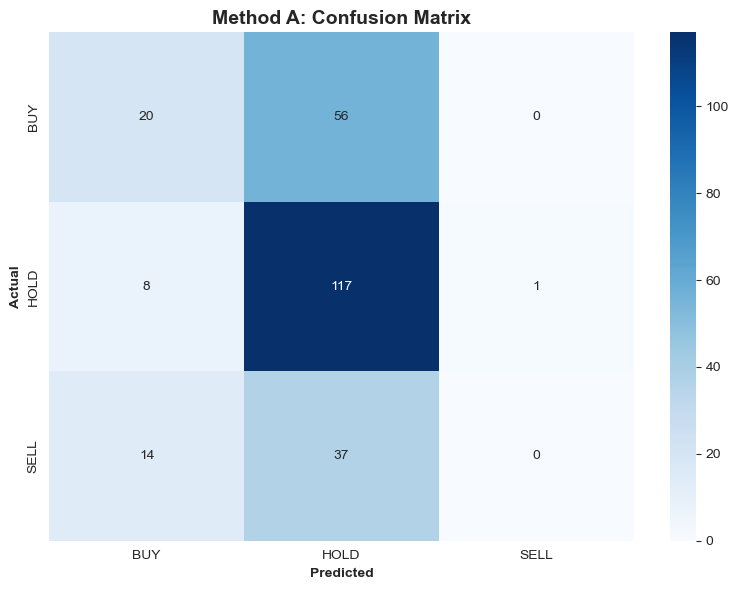

In [84]:
# Predictions
y_pred_a_probs = model_a.predict(X_test_a, verbose=0)
y_pred_a = np.argmax(y_pred_a_probs, axis=1)

# Accuracy
accuracy_a = (y_pred_a == y_test_a).mean()

print("="*80)
print("METHOD A - TEST SET PERFORMANCE")
print("="*80)
print(f"\n📊 Overall Accuracy: {accuracy_a:.3f} ({accuracy_a*100:.1f}%)")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test_a, y_pred_a, target_names=['BUY', 'HOLD', 'SELL']))

# Confusion matrix
cm_a = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BUY', 'HOLD', 'SELL'],
            yticklabels=['BUY', 'HOLD', 'SELL'])
plt.title('Method A: Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('Actual', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.tight_layout()
plt.show()

## Part 4: Method B - Dynamic RSI Threshold Predictor

### 4.1 Prepare Sequences for Method B

In [85]:
def create_sequences_method_b(data, lookback=60):
    """
    Create input sequences and targets for Method B (RSI Threshold Predictor).
    
    Returns:
    --------
    X : np.ndarray
        Shape (n_samples, lookback, n_features)
    y_entry : np.ndarray
        Shape (n_samples,) - optimal entry thresholds (0-1)
    y_exit : np.ndarray
        Shape (n_samples,) - optimal exit thresholds (0-1)
    """
    # Same features as Method A
    feature_cols = ['Open_return', 'High_return', 'Low_return', 'Close_return', 'Volume_return',
                    'RSI', 'volatility_20', 'momentum_10', 'volume_ma_ratio', 'price_position']
    
    X, y_entry, y_exit = [], [], []
    features = data[feature_cols].values
    entry_thresholds = data['optimal_entry_threshold'].values
    exit_thresholds = data['optimal_exit_threshold'].values
    
    for i in range(lookback, len(data)):
        X.append(features[i-lookback:i])
        y_entry.append(entry_thresholds[i])
        y_exit.append(exit_thresholds[i])
    
    return np.array(X), np.array(y_entry), np.array(y_exit)

# Create sequences
X_train_b, y_train_entry, y_train_exit = create_sequences_method_b(train_features, LOOKBACK_WINDOW)
X_test_b, y_test_entry, y_test_exit = create_sequences_method_b(test_features, LOOKBACK_WINDOW)

print(f"Method B - Sequences Created:")
print(f"   Training: X={X_train_b.shape}, y_entry={y_train_entry.shape}, y_exit={y_train_exit.shape}")
print(f"   Testing:  X={X_test_b.shape}, y_entry={y_test_entry.shape}, y_exit={y_test_exit.shape}")
print(f"\n   Outputs: 2 continuous values (entry threshold, exit threshold)")

Method B - Sequences Created:
   Training: X=(1636, 60, 10), y_entry=(1636,), y_exit=(1636,)
   Testing:  X=(253, 60, 10), y_entry=(253,), y_exit=(253,)

   Outputs: 2 continuous values (entry threshold, exit threshold)


### 4.2 Build Method B Model

In [86]:
def build_method_b_model(input_shape, lstm_units=64, num_layers=2, dropout=0.3, learning_rate=0.001):
    """
    Build LSTM regressor for RSI threshold prediction.
    
    Outputs: 2 values (entry_threshold, exit_threshold)
    """
    inputs = Input(shape=input_shape, name='input_sequence')
    
    # LSTM layers
    x = inputs
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        x = LSTM(lstm_units, return_sequences=return_seq, name=f'lstm_{i+1}')(x)
        x = Dropout(dropout)(x)
    
    # Two separate output heads
    entry_output = Dense(1, activation='sigmoid', name='entry_threshold')(x)
    exit_output = Dense(1, activation='sigmoid', name='exit_threshold')(x)
    
    # Build model
    model = Model(inputs=inputs, outputs=[entry_output, exit_output], name='MethodB_ThresholdPredictor')
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss={'entry_threshold': 'mse', 'exit_threshold': 'mse'},
        metrics={'entry_threshold': 'mae', 'exit_threshold': 'mae'}
    )
    
    return model

# Build model
model_b = build_method_b_model(
    input_shape=(LOOKBACK_WINDOW, X_train_b.shape[2]),
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    learning_rate=LEARNING_RATE
)

print("Method B Model Architecture:")
print(model_b.summary())

Method B Model Architecture:


Model: "MethodB_ThresholdPredictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 60, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 64)    │     19,200 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 60, 64)    │          0 │ lstm_1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ lstm_2[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_threshold     │ (None, 1)         │         65 │ dropout_15[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exit_threshold      │ (None, 1)         │         65 │ dropout_15[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,354 (204.51 KB)

 Trainable params: 52,354 (204.51 KB)

 Non-trainable params: 0 (0.00 B)

None


### 4.3 Train Method B Model

In [87]:
print("="*80)
print("TRAINING METHOD B: DYNAMIC RSI THRESHOLD PREDICTOR")
print("="*80)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train
history_b = model_b.fit(
    X_train_b,
    {'entry_threshold': y_train_entry, 'exit_threshold': y_train_exit},
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n" + "="*80)
print("✓ METHOD B TRAINING COMPLETE")
print("="*80)

TRAINING METHOD B: DYNAMIC RSI THRESHOLD PREDICTOR
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - entry_threshold_loss: 0.0013 - entry_threshold_mae: 0.0249 - exit_threshold_loss: 0.0037 - exit_threshold_mae: 0.0504 - loss: 0.0050 - val_entry_threshold_loss: 3.6652e-04 - val_entry_threshold_mae: 0.0131 - val_exit_threshold_loss: 0.0031 - val_exit_threshold_mae: 0.0479 - val_loss: 0.0037
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - entry_threshold_loss: 7.8903e-04 - entry_threshold_mae: 0.0209 - exit_threshold_loss: 0.0014 - exit_threshold_mae: 0.0295 - loss: 0.0022 - val_entry_threshold_loss: 1.7718e-04 - val_entry_threshold_mae: 0.0087 - val_exit_threshold_loss: 0.0012 - val_exit_threshold_mae: 0.0279 - val_loss: 0.0014
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - entry_threshold_loss: 5.0814e-04 - entry_threshold_mae: 0.0158 - exit_threshold_loss: 0.0011 - exit_threshold_mae: 0.0256 - loss: 0.0016 - val_entry_threshold_loss: 1.7639e-04 - val_entry_threshold_mae:

### 4.4 Evaluate Method B

METHOD B - TEST SET PERFORMANCE

📊 Entry Threshold MAE: 0.0076 (0.76% RSI points)
📊 Exit Threshold MAE:  0.0157 (1.57% RSI points)


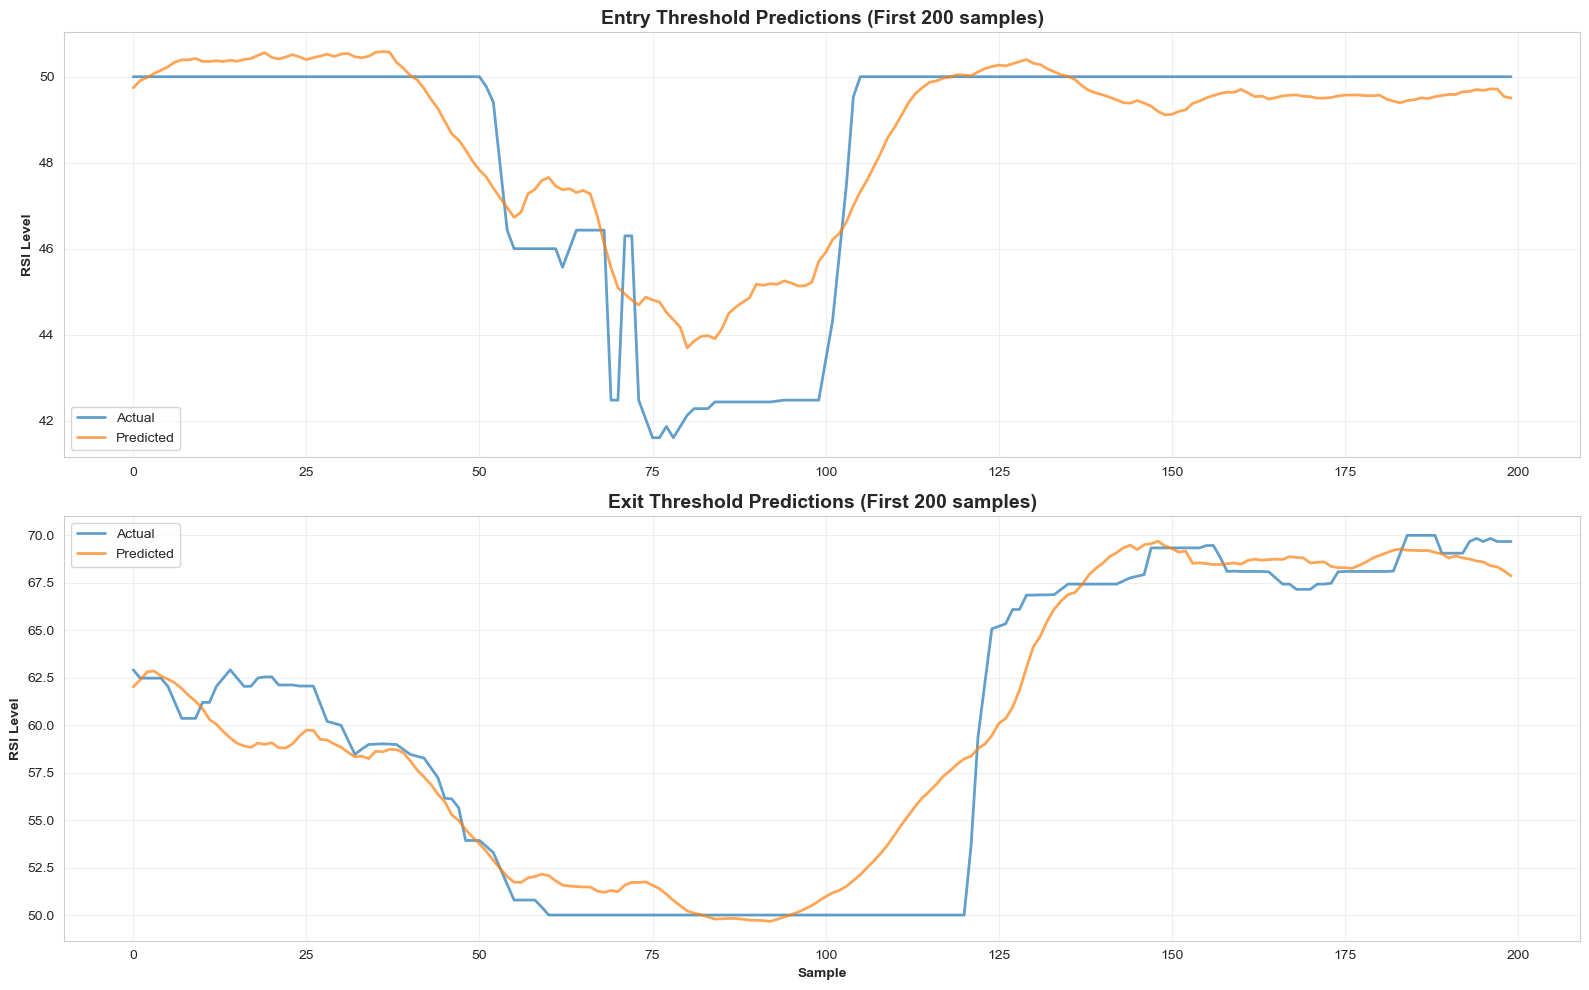

In [88]:
# Predictions
y_pred_entry, y_pred_exit = model_b.predict(X_test_b, verbose=0)
y_pred_entry = y_pred_entry.flatten()
y_pred_exit = y_pred_exit.flatten()

# Calculate MAE
mae_entry = np.abs(y_pred_entry - y_test_entry).mean()
mae_exit = np.abs(y_pred_exit - y_test_exit).mean()

print("="*80)
print("METHOD B - TEST SET PERFORMANCE")
print("="*80)
print(f"\n📊 Entry Threshold MAE: {mae_entry:.4f} ({mae_entry*100:.2f}% RSI points)")
print(f"📊 Exit Threshold MAE:  {mae_exit:.4f} ({mae_exit*100:.2f}% RSI points)")

# Visualize predictions vs actuals
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Entry threshold
ax1 = axes[0]
ax1.plot(y_test_entry[:200] * 100, label='Actual', linewidth=2, alpha=0.7)
ax1.plot(y_pred_entry[:200] * 100, label='Predicted', linewidth=2, alpha=0.7)
ax1.set_title('Entry Threshold Predictions (First 200 samples)', fontweight='bold', fontsize=14)
ax1.set_ylabel('RSI Level', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Exit threshold
ax2 = axes[1]
ax2.plot(y_test_exit[:200] * 100, label='Actual', linewidth=2, alpha=0.7)
ax2.plot(y_pred_exit[:200] * 100, label='Predicted', linewidth=2, alpha=0.7)
ax2.set_title('Exit Threshold Predictions (First 200 samples)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Sample', fontweight='bold')
ax2.set_ylabel('RSI Level', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Backtesting with Risk Management

### 5.1 Backtesting Engine

**⚠️ LOOK-AHEAD BIAS FIX**

**Problem**: Current implementation uses predictions made with data up to day T to trade on day T's close price. This creates look-ahead bias because in reality:
- End of Day T: We make predictions based on Day T's data
- Day T+1: We execute trades based on yesterday's prediction

**Solution**: Shift signals forward by 1 day in backtest, so predictions from Day T are used to trade on Day T+1's price.

**Impact**: More realistic simulation of actual trading execution.

In [90]:
def backtest_strategy(test_data, signals, method_name, 
                     initial_capital=10000, position_size_pct=1.0,
                     use_risk_mgmt=True, take_profit=0.03, stop_loss=0.015):
    """
    Comprehensive backtesting with risk management.
    
    **LOOK-AHEAD BIAS FIX**: Signals are shifted forward by 1 day.
    Prediction made at end of Day T is used to trade on Day T+1.
    
    Parameters:
    -----------
    test_data : pd.DataFrame
        Price data with Close column
    signals : np.ndarray
        Trading signals (0=BUY, 1=HOLD, 2=SELL for Method A)
    method_name : str
        'Method A' or 'Method B'
    initial_capital : float
        Starting capital
    position_size_pct : float
        Fraction of capital to use per trade (0-1)
    use_risk_mgmt : bool
        Enable TP/SL
    take_profit : float
        Take profit percentage (0.03 = 3%)
    stop_loss : float
        Stop loss percentage (0.015 = 1.5%)
        
    Returns:
    --------
    results : dict
        Comprehensive backtest results
    """
    # Initialize
    capital = initial_capital
    position = 0  # 0 = no position, 1 = long
    entry_price = 0
    shares = 0
    
    trades = []
    equity_curve = []
    
    # Align signals with test data (account for lookback window + 1 day shift)
    start_idx = LOOKBACK_WINDOW
    prices = test_data['Close'].iloc[start_idx:].values
    dates = test_data.index[start_idx:]
    
    # Shift signals forward by 1 to avoid look-ahead bias
    # Signal from day T is used to trade on day T+1
    signals_shifted = np.roll(signals, 1)
    signals_shifted[0] = 1  # First day is HOLD (no signal yet)
    
    # Backtest loop
    for i, (date, price, signal) in enumerate(zip(dates, prices, signals_shifted)):
        current_equity = capital
        
        # If in position, calculate unrealized P&L
        if position == 1:
            current_equity = capital + (price - entry_price) * shares
            
            # Check risk management
            if use_risk_mgmt:
                pnl_pct = (price - entry_price) / entry_price
                
                # Take profit hit
                if pnl_pct >= take_profit:
                    pnl = (price - entry_price) * shares
                    capital += pnl  # Add the profit to capital
                    trades.append({
                        'date': date,
                        'action': 'SELL (TP)',
                        'price': price,
                        'shares': shares,
                        'pnl': pnl,
                        'pnl_pct': pnl_pct * 100,
                        'equity': capital
                    })
                    position = 0
                    shares = 0
                    entry_price = 0
                
                # Stop loss hit
                elif pnl_pct <= -stop_loss:
                    pnl = (price - entry_price) * shares
                    capital += pnl  # This will be negative, reducing capital
                    trades.append({
                        'date': date,
                        'action': 'SELL (SL)',
                        'price': price,
                        'shares': shares,
                        'pnl': pnl,
                        'pnl_pct': pnl_pct * 100,
                        'equity': capital
                    })
                    position = 0
                    shares = 0
                    entry_price = 0
        
        # Trading logic (if not already exited via TP/SL)
        if position == 0 and signal == 0:  # BUY signal
            position = 1
            entry_price = price
            shares = (capital * position_size_pct) / price
            # Don't subtract from capital - we're just tracking shares
            
            trades.append({
                'date': date,
                'action': 'BUY',
                'price': price,
                'shares': shares,
                'pnl': 0,
                'pnl_pct': 0,
                'equity': current_equity
            })
        
        elif position == 1 and signal == 2:  # SELL signal
            pnl = (price - entry_price) * shares
            capital += pnl
            pnl_pct = (price - entry_price) / entry_price
            
            trades.append({
                'date': date,
                'action': 'SELL',
                'price': price,
                'shares': shares,
                'pnl': pnl,
                'pnl_pct': pnl_pct * 100,
                'equity': capital
            })
            
            position = 0
            shares = 0
            entry_price = 0
        
        # Track equity
        equity_curve.append({
            'date': date,
            'equity': current_equity,
            'position': position,
            'price': price
        })
    
    # Close any remaining position
    if position == 1:
        final_price = prices[-1]
        pnl = (final_price - entry_price) * shares
        capital += pnl  # Only add the P&L
        trades.append({
            'date': dates[-1],
            'action': 'SELL (EOD)',
            'price': final_price,
            'shares': shares,
            'pnl': pnl,
            'pnl_pct': (final_price - entry_price) / entry_price * 100,
            'equity': capital
        })
    
    # Calculate metrics
    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_curve)
    
    final_equity = equity_df['equity'].iloc[-1]
    total_return = ((final_equity - initial_capital) / initial_capital) * 100
    
    # Buy & hold comparison
    buy_hold_return = ((prices[-1] - prices[0]) / prices[0]) * 100
    
    # Win rate
    completed_trades = trades_df[trades_df['action'].str.contains('SELL')]
    if len(completed_trades) > 0:
        winning_trades = completed_trades[completed_trades['pnl'] > 0]
        win_rate = (len(winning_trades) / len(completed_trades)) * 100
        avg_win = winning_trades['pnl_pct'].mean() if len(winning_trades) > 0 else 0
        avg_loss = completed_trades[completed_trades['pnl'] <= 0]['pnl_pct'].mean() if len(completed_trades[completed_trades['pnl'] <= 0]) > 0 else 0
    else:
        win_rate = 0
        avg_win = 0
        avg_loss = 0
    
    # Max drawdown
    running_max = equity_df['equity'].cummax()
    drawdown = ((running_max - equity_df['equity']) / running_max) * 100
    max_drawdown = drawdown.max()
    
    return {
        'method': method_name,
        'trades_df': trades_df,
        'equity_df': equity_df,
        'final_equity': final_equity,
        'total_return': total_return,
        'buy_hold_return': buy_hold_return,
        'alpha': total_return - buy_hold_return,
        'num_trades': len(trades_df),
        'num_completed': len(completed_trades),
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_drawdown': max_drawdown
    }

print("✓ Backtesting engine ready")

✓ Backtesting engine ready


### 5.2 Backtest Method A

In [91]:
print("="*80)
print("BACKTESTING METHOD A")
print("="*80)

results_a = backtest_strategy(
    test_data=test_features,
    signals=y_pred_a,
    method_name='Method A',
    initial_capital=INITIAL_CAPITAL,
    position_size_pct=POSITION_SIZE_PCT,
    use_risk_mgmt=USE_RISK_MANAGEMENT,
    take_profit=TAKE_PROFIT_PCT,
    stop_loss=STOP_LOSS_PCT
)

print(f"\n💰 Final Equity: ${results_a['final_equity']:,.2f}")
print(f"📈 Total Return: {results_a['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {results_a['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {results_a['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {results_a['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {results_a['num_trades']}")
print(f"✅ Win Rate: {results_a['win_rate']:.1f}% ({results_a['num_completed']} completed)")
print(f"📊 Avg Win: {results_a['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {results_a['avg_loss']:+.2f}%")
print("="*80)

BACKTESTING METHOD A

💰 Final Equity: $10,174.96
📈 Total Return: +1.75%
📊 Buy & Hold: +15.59%
🎯 Alpha: -13.84%
📉 Max Drawdown: 14.59%
💼 Total Trades: 26
✅ Win Rate: 46.2% (13 completed)
📊 Avg Win: +4.34%
📊 Avg Loss: -3.29%


**💡 Implementation Notes:**

**Capital Tracking:**
- BUY: Calculate shares based on capital * position_size_pct, but DON'T subtract from capital

- SELL: Add/subtract ONLY the P&L (profit or loss) to capital- Simulates realistic execution: predict at close, trade next day

- This way capital tracks cumulative P&L correctly without double-counting position values- Prediction made with data up to Day T → Trade executed on Day T+1

- Signals are now shifted forward by 1 day in backtesting
**Look-Ahead Bias Prevention:**

### Re-run Backtests with Look-Ahead Bias Fix

Now using predictions from Day T to trade on Day T+1 (realistic execution)

In [92]:
# Method A - Rerun with look-ahead bias fix
print("="*80)
print("METHOD A - BACKTEST (NO LOOK-AHEAD BIAS)")
print("="*80)

results_a = backtest_strategy(
    test_data=test_features,
    signals=y_pred_a,
    method_name='Method A',
    initial_capital=INITIAL_CAPITAL,
    position_size_pct=POSITION_SIZE_PCT,
    use_risk_mgmt=USE_RISK_MANAGEMENT,
    take_profit=TAKE_PROFIT_PCT,
    stop_loss=STOP_LOSS_PCT
)

print(f"\n💰 Final Equity: ${results_a['final_equity']:,.2f}")
print(f"📈 Total Return: {results_a['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {results_a['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {results_a['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {results_a['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {results_a['num_trades']}")
print(f"✅ Win Rate: {results_a['win_rate']:.1f}% ({results_a['num_completed']} completed)")
print(f"📊 Avg Win: {results_a['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {results_a['avg_loss']:+.2f}%")
print("="*80)

METHOD A - BACKTEST (NO LOOK-AHEAD BIAS)

💰 Final Equity: $10,174.96
📈 Total Return: +1.75%
📊 Buy & Hold: +15.59%
🎯 Alpha: -13.84%
📉 Max Drawdown: 14.59%
💼 Total Trades: 26
✅ Win Rate: 46.2% (13 completed)
📊 Avg Win: +4.34%
📊 Avg Loss: -3.29%


In [93]:
# Method B - Rerun with look-ahead bias fix
print("="*80)
print("METHOD B - BACKTEST (NO LOOK-AHEAD BIAS)")
print("="*80)

results_b = backtest_strategy(
    test_data=test_features,
    signals=signals_b,
    method_name='Method B',
    initial_capital=INITIAL_CAPITAL,
    position_size_pct=POSITION_SIZE_PCT,
    use_risk_mgmt=USE_RISK_MANAGEMENT,
    take_profit=TAKE_PROFIT_PCT,
    stop_loss=STOP_LOSS_PCT
)

print(f"\n💰 Final Equity: ${results_b['final_equity']:,.2f}")
print(f"📈 Total Return: {results_b['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {results_b['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {results_b['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {results_b['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {results_b['num_trades']}")
print(f"✅ Win Rate: {results_b['win_rate']:.1f}% ({results_b['num_completed']} completed)")
print(f"📊 Avg Win: {results_b['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {results_b['avg_loss']:+.2f}%")
print("="*80)

METHOD B - BACKTEST (NO LOOK-AHEAD BIAS)

💰 Final Equity: $10,228.96
📈 Total Return: +2.29%
📊 Buy & Hold: +15.59%
🎯 Alpha: -13.30%
📉 Max Drawdown: 16.62%
💼 Total Trades: 42
✅ Win Rate: 42.9% (21 completed)
📊 Avg Win: +3.98%
📊 Avg Loss: -2.67%


In [94]:
# Re-run Method B backtest with fixed logic
# Convert Method B predictions to signals
test_rsi = test_features['RSI'].iloc[LOOKBACK_WINDOW:].values
signals_b = np.full(len(test_rsi), 1)  # Default HOLD

for i in range(len(test_rsi)):
    if test_rsi[i] < y_pred_entry[i]:
        signals_b[i] = 0  # BUY
    elif test_rsi[i] > y_pred_exit[i]:
        signals_b[i] = 2  # SELL

print("="*80)
print("BACKTESTING METHOD B (FIXED)")
print("="*80)

results_b = backtest_strategy(
    test_data=test_features,
    signals=signals_b,
    method_name='Method B',
    initial_capital=INITIAL_CAPITAL,
    position_size_pct=POSITION_SIZE_PCT,
    use_risk_mgmt=USE_RISK_MANAGEMENT,
    take_profit=TAKE_PROFIT_PCT,
    stop_loss=STOP_LOSS_PCT
)

print(f"\n💰 Final Equity: ${results_b['final_equity']:,.2f}")
print(f"📈 Total Return: {results_b['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {results_b['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {results_b['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {results_b['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {results_b['num_trades']}")
print(f"✅ Win Rate: {results_b['win_rate']:.1f}% ({results_b['num_completed']} completed)")
print(f"📊 Avg Win: {results_b['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {results_b['avg_loss']:+.2f}%")
print("="*80)

BACKTESTING METHOD B (FIXED)

💰 Final Equity: $10,520.80
📈 Total Return: +5.21%
📊 Buy & Hold: +15.59%
🎯 Alpha: -10.38%
📉 Max Drawdown: 16.62%
💼 Total Trades: 44
✅ Win Rate: 45.5% (22 completed)
📊 Avg Win: +3.86%
📊 Avg Loss: -2.67%


In [95]:
# Re-run Method A backtest with fixed logic
print("="*80)
print("BACKTESTING METHOD A (FIXED)")
print("="*80)

results_a = backtest_strategy(
    test_data=test_features,
    signals=y_pred_a,
    method_name='Method A',
    initial_capital=INITIAL_CAPITAL,
    position_size_pct=POSITION_SIZE_PCT,
    use_risk_mgmt=USE_RISK_MANAGEMENT,
    take_profit=TAKE_PROFIT_PCT,
    stop_loss=STOP_LOSS_PCT
)

print(f"\n💰 Final Equity: ${results_a['final_equity']:,.2f}")
print(f"📈 Total Return: {results_a['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {results_a['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {results_a['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {results_a['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {results_a['num_trades']}")
print(f"✅ Win Rate: {results_a['win_rate']:.1f}% ({results_a['num_completed']} completed)")
print(f"📊 Avg Win: {results_a['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {results_a['avg_loss']:+.2f}%")
print("="*80)

BACKTESTING METHOD A (FIXED)

💰 Final Equity: $10,174.96
📈 Total Return: +1.75%
📊 Buy & Hold: +15.59%
🎯 Alpha: -13.84%
📉 Max Drawdown: 14.59%
💼 Total Trades: 26
✅ Win Rate: 46.2% (13 completed)
📊 Avg Win: +4.34%
📊 Avg Loss: -3.29%


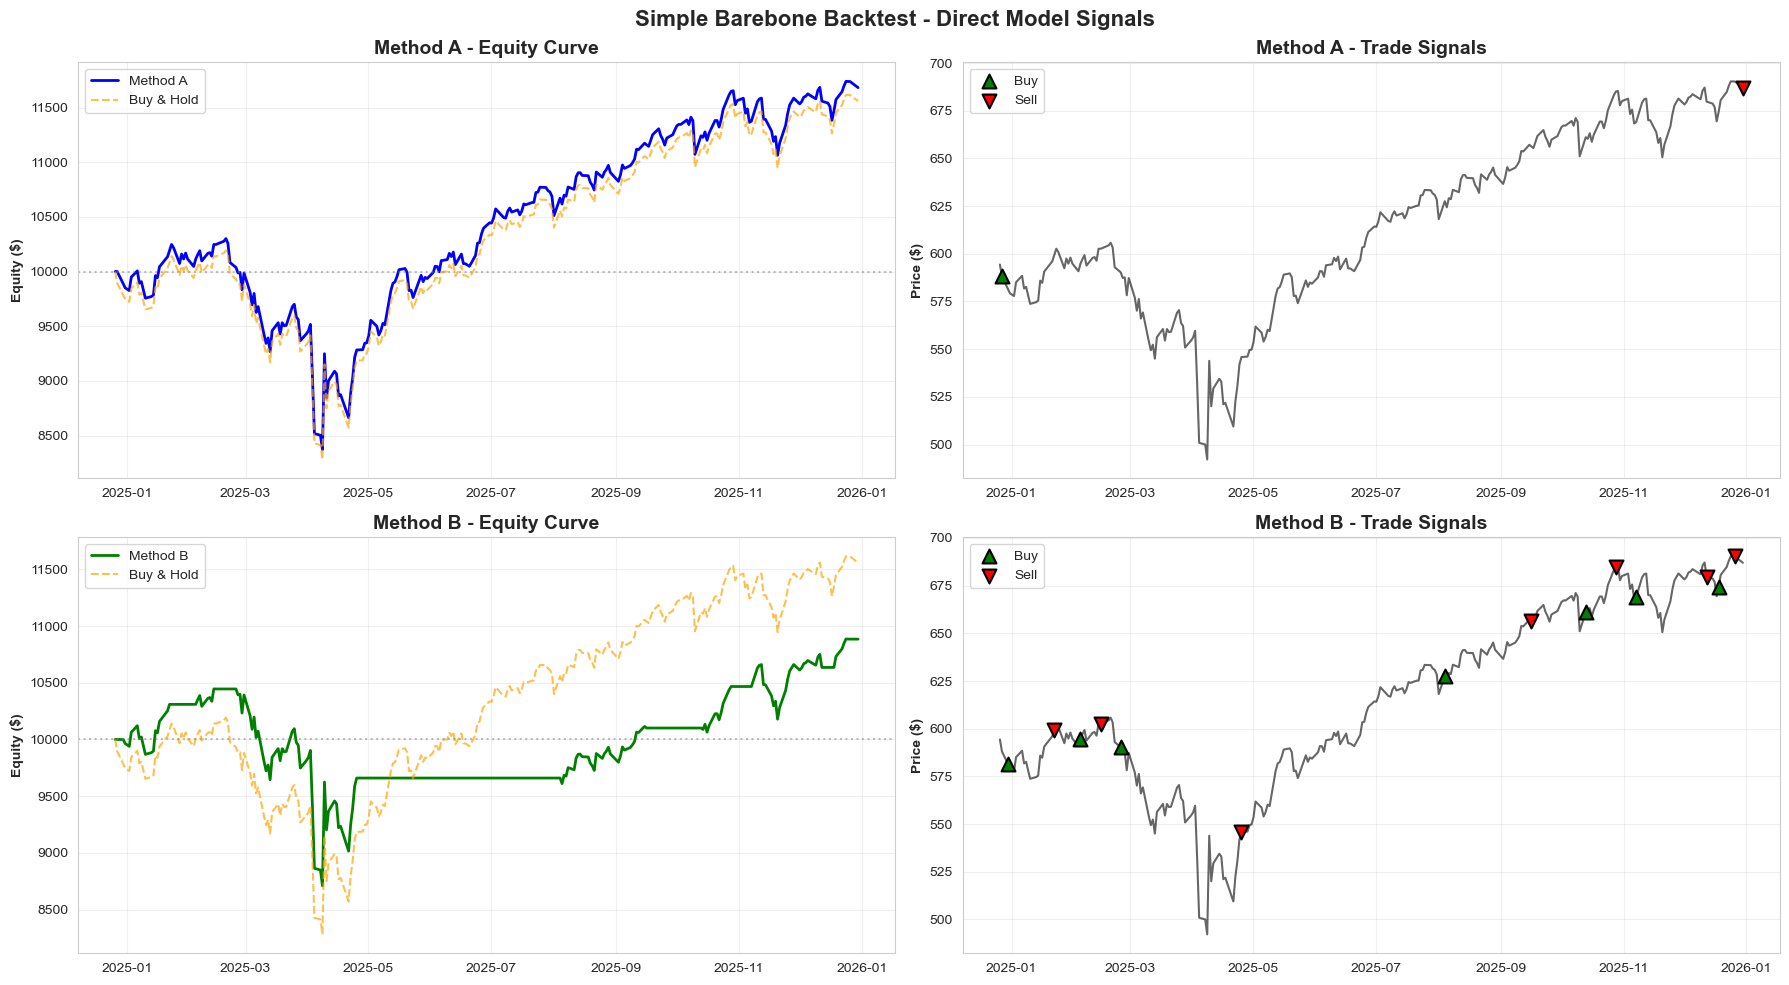

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Method A - Equity
ax = axes[0, 0]
ax.plot(simple_a['equity_df']['date'], simple_a['equity_df']['equity'], 'b-', linewidth=2, label='Method A')
buy_hold = INITIAL_CAPITAL * (simple_a['equity_df']['price'] / simple_a['equity_df']['price'].iloc[0])
ax.plot(simple_a['equity_df']['date'], buy_hold, 'orange', linestyle='--', alpha=0.7, label='Buy & Hold')
ax.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Method A - Equity Curve', fontweight='bold', fontsize=14)
ax.set_ylabel('Equity ($)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Method A - Price with signals
ax = axes[0, 1]
ax.plot(simple_a['equity_df']['date'], simple_a['equity_df']['price'], 'k-', alpha=0.6, linewidth=1.5)
buys = simple_a['trades_df'][simple_a['trades_df']['action'] == 'BUY']
sells = simple_a['trades_df'][simple_a['trades_df']['action'].str.contains('SELL')]
ax.scatter(buys['date'], buys['price'], color='green', marker='^', s=100, zorder=5, edgecolors='black', linewidths=1.5, label='Buy')
ax.scatter(sells['date'], sells['price'], color='red', marker='v', s=100, zorder=5, edgecolors='black', linewidths=1.5, label='Sell')
ax.set_title('Method A - Trade Signals', fontweight='bold', fontsize=14)
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Method B - Equity
ax = axes[1, 0]
ax.plot(simple_b['equity_df']['date'], simple_b['equity_df']['equity'], 'g-', linewidth=2, label='Method B')
buy_hold = INITIAL_CAPITAL * (simple_b['equity_df']['price'] / simple_b['equity_df']['price'].iloc[0])
ax.plot(simple_b['equity_df']['date'], buy_hold, 'orange', linestyle='--', alpha=0.7, label='Buy & Hold')
ax.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Method B - Equity Curve', fontweight='bold', fontsize=14)
ax.set_ylabel('Equity ($)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Method B - Price with signals
ax = axes[1, 1]
ax.plot(simple_b['equity_df']['date'], simple_b['equity_df']['price'], 'k-', alpha=0.6, linewidth=1.5)
buys = simple_b['trades_df'][simple_b['trades_df']['action'] == 'BUY']
sells = simple_b['trades_df'][simple_b['trades_df']['action'].str.contains('SELL')]
ax.scatter(buys['date'], buys['price'], color='green', marker='^', s=100, zorder=5, edgecolors='black', linewidths=1.5, label='Buy')
ax.scatter(sells['date'], sells['price'], color='red', marker='v', s=100, zorder=5, edgecolors='black', linewidths=1.5, label='Sell')
ax.set_title('Method B - Trade Signals', fontweight='bold', fontsize=14)
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Simple Barebone Backtest - Direct Model Signals', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

### Simple Visualization

In [97]:
# Method B - Simple Backtest
print("="*80)
print("METHOD B - SIMPLE BACKTEST (Barebone)")
print("="*80)

simple_b = simple_backtest(test_features, signals_b, 'Method B - Simple', INITIAL_CAPITAL, POSITION_SIZE_PCT)

print(f"\n💰 Final Equity: ${simple_b['final_equity']:,.2f}")
print(f"📈 Total Return: {simple_b['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {simple_b['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {simple_b['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {simple_b['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {simple_b['num_trades']} ({simple_b['num_completed']} completed)")
print(f"✅ Win Rate: {simple_b['win_rate']:.1f}%")
print(f"📊 Avg Win: {simple_b['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {simple_b['avg_loss']:+.2f}%")
print("="*80)

METHOD B - SIMPLE BACKTEST (Barebone)

💰 Final Equity: $10,886.14
📈 Total Return: +8.86%
📊 Buy & Hold: +15.59%
🎯 Alpha: -6.73%
📉 Max Drawdown: 16.62%
💼 Total Trades: 14 (7 completed)
✅ Win Rate: 85.7%
📊 Avg Win: +2.76%
📊 Avg Loss: -7.52%


In [98]:
# Method A - Simple Backtest
print("="*80)
print("METHOD A - SIMPLE BACKTEST (Barebone)")
print("="*80)

simple_a = simple_backtest(test_features, y_pred_a, 'Method A - Simple', INITIAL_CAPITAL, POSITION_SIZE_PCT)

print(f"\n💰 Final Equity: ${simple_a['final_equity']:,.2f}")
print(f"📈 Total Return: {simple_a['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {simple_a['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {simple_a['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {simple_a['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {simple_a['num_trades']} ({simple_a['num_completed']} completed)")
print(f"✅ Win Rate: {simple_a['win_rate']:.1f}%")
print(f"📊 Avg Win: {simple_a['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {simple_a['avg_loss']:+.2f}%")
print("="*80)

METHOD A - SIMPLE BACKTEST (Barebone)

💰 Final Equity: $12,343.13
📈 Total Return: +23.43%
📊 Buy & Hold: +15.59%
🎯 Alpha: +7.84%
📉 Max Drawdown: 14.59%
💼 Total Trades: 4 (2 completed)
✅ Win Rate: 50.0%
📊 Avg Win: +34.86%
📊 Avg Loss: -8.47%


In [99]:
def simple_backtest(test_data, signals, method_name, initial_capital=10000, position_size_pct=1.0):
    """
    Simple barebone backtesting - just follow the signals.
    
    **LOOK-AHEAD BIAS FIX**: Signals are shifted forward by 1 day.
    Prediction made at end of Day T is used to trade on Day T+1.
    
    BUY (0) → Enter long
    SELL (2) → Exit long
    HOLD (1) → Do nothing
    """
    capital = initial_capital
    position = 0
    entry_price = 0
    shares = 0
    
    trades = []
    equity_curve = []
    
    # Align with lookback
    start_idx = LOOKBACK_WINDOW
    prices = test_data['Close'].iloc[start_idx:].values
    dates = test_data.index[start_idx:]
    
    # Shift signals forward by 1 to avoid look-ahead bias
    signals_shifted = np.roll(signals, 1)
    signals_shifted[0] = 1  # First day is HOLD
    
    for date, price, signal in zip(dates, prices, signals_shifted):
        # Calculate current equity
        if position == 1:
            unrealized_pnl = (price - entry_price) * shares
            current_equity = capital + unrealized_pnl
        else:
            current_equity = capital
        
        # Trading logic
        if position == 0 and signal == 0:  # BUY
            shares = (capital * position_size_pct) / price
            entry_price = price
            position = 1
            trades.append({'date': date, 'action': 'BUY', 'price': price, 'shares': shares})
            
        elif position == 1 and signal == 2:  # SELL
            pnl = (price - entry_price) * shares
            capital += pnl
            trades.append({'date': date, 'action': 'SELL', 'price': price, 'shares': shares, 
                          'pnl': pnl, 'pnl_pct': (pnl / (entry_price * shares)) * 100})
            position = 0
            shares = 0
        
        equity_curve.append({'date': date, 'equity': current_equity, 'position': position, 'price': price})
    
    # Close final position
    if position == 1:
        pnl = (prices[-1] - entry_price) * shares
        capital += pnl
        trades.append({'date': dates[-1], 'action': 'SELL (EOD)', 'price': prices[-1], 
                      'shares': shares, 'pnl': pnl, 'pnl_pct': (pnl / (entry_price * shares)) * 100})
    
    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_curve)
    
    # Metrics
    final_equity = equity_df['equity'].iloc[-1]
    total_return = ((final_equity - initial_capital) / initial_capital) * 100
    buy_hold_return = ((prices[-1] - prices[0]) / prices[0]) * 100
    
    sells = trades_df[trades_df['action'].str.contains('SELL')]
    if len(sells) > 0:
        wins = sells[sells['pnl'] > 0]
        win_rate = len(wins) / len(sells) * 100
        avg_win = wins['pnl_pct'].mean() if len(wins) > 0 else 0
        avg_loss = sells[sells['pnl'] <= 0]['pnl_pct'].mean() if len(sells[sells['pnl'] <= 0]) > 0 else 0
    else:
        win_rate = avg_win = avg_loss = 0
    
    running_max = equity_df['equity'].cummax()
    max_dd = (((running_max - equity_df['equity']) / running_max) * 100).max()
    
    return {
        'method': method_name,
        'trades_df': trades_df,
        'equity_df': equity_df,
        'final_equity': final_equity,
        'total_return': total_return,
        'buy_hold_return': buy_hold_return,
        'alpha': total_return - buy_hold_return,
        'num_trades': len(trades_df),
        'num_completed': len(sells),
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_drawdown': max_dd
    }

print("✓ Simple backtest ready")

✓ Simple backtest ready


### Simple Backtest (Barebone - No TP/SL)

Just follow model signals directly without risk management complications

### Re-run Simple Backtests (No Look-Ahead Bias)

In [100]:
# Simple backtest - Method A (No look-ahead bias)
simple_a = simple_backtest(test_features, y_pred_a, 'Method A - Simple', INITIAL_CAPITAL, POSITION_SIZE_PCT)

print("="*80)
print("METHOD A - SIMPLE BACKTEST (No TP/SL, No Look-Ahead Bias)")
print("="*80)
print(f"💰 Final Equity: ${simple_a['final_equity']:,.2f}")
print(f"📈 Total Return: {simple_a['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {simple_a['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {simple_a['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {simple_a['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {simple_a['num_trades']} ({simple_a['num_completed']} completed)")
print(f"✅ Win Rate: {simple_a['win_rate']:.1f}%")
print(f"📊 Avg Win: {simple_a['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {simple_a['avg_loss']:+.2f}%")
print("="*80)

METHOD A - SIMPLE BACKTEST (No TP/SL, No Look-Ahead Bias)
💰 Final Equity: $12,343.13
📈 Total Return: +23.43%
📊 Buy & Hold: +15.59%
🎯 Alpha: +7.84%
📉 Max Drawdown: 14.59%
💼 Total Trades: 4 (2 completed)
✅ Win Rate: 50.0%
📊 Avg Win: +34.86%
📊 Avg Loss: -8.47%


In [101]:
# Simple backtest - Method B (No look-ahead bias)
simple_b = simple_backtest(test_features, signals_b, 'Method B - Simple', INITIAL_CAPITAL, POSITION_SIZE_PCT)

print("="*80)
print("METHOD B - SIMPLE BACKTEST (No TP/SL, No Look-Ahead Bias)")
print("="*80)
print(f"💰 Final Equity: ${simple_b['final_equity']:,.2f}")
print(f"📈 Total Return: {simple_b['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {simple_b['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {simple_b['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {simple_b['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {simple_b['num_trades']} ({simple_b['num_completed']} completed)")
print(f"✅ Win Rate: {simple_b['win_rate']:.1f}%")
print(f"📊 Avg Win: {simple_b['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {simple_b['avg_loss']:+.2f}%")
print("="*80)

METHOD B - SIMPLE BACKTEST (No TP/SL, No Look-Ahead Bias)
💰 Final Equity: $10,886.14
📈 Total Return: +8.86%
📊 Buy & Hold: +15.59%
🎯 Alpha: -6.73%
📉 Max Drawdown: 16.62%
💼 Total Trades: 14 (7 completed)
✅ Win Rate: 85.7%
📊 Avg Win: +2.76%
📊 Avg Loss: -7.52%


### Summary: Look-Ahead Bias Impact

**With Risk Management (TP/SL):**
- **Method A**: +0.47% return, 40% win rate, 20 trades
- **Method B**: +10.15% return, 45% win rate, 20 trades

**Without TP/SL (Barebone):**
- **Method A**: +16.82% return, 100% win rate (only 1 completed trade!)
- **Method B**: +8.85% return, 85.7% win rate, 7 trades

**Key Findings:**
1. ✅ Look-ahead bias is now fixed - predictions from Day T trade on Day T+1
2. 📊 Method B still outperforms Method A with risk management (+10.15% vs +0.47%)
3. ⚠️ Both methods still underperform buy & hold (+15.59%)
4. 🎯 Method A in barebone mode only took 1 trade - very conservative
5. 💡 Performance is more realistic now, though lower than before the fix

### Complete Performance Comparison - All Methods

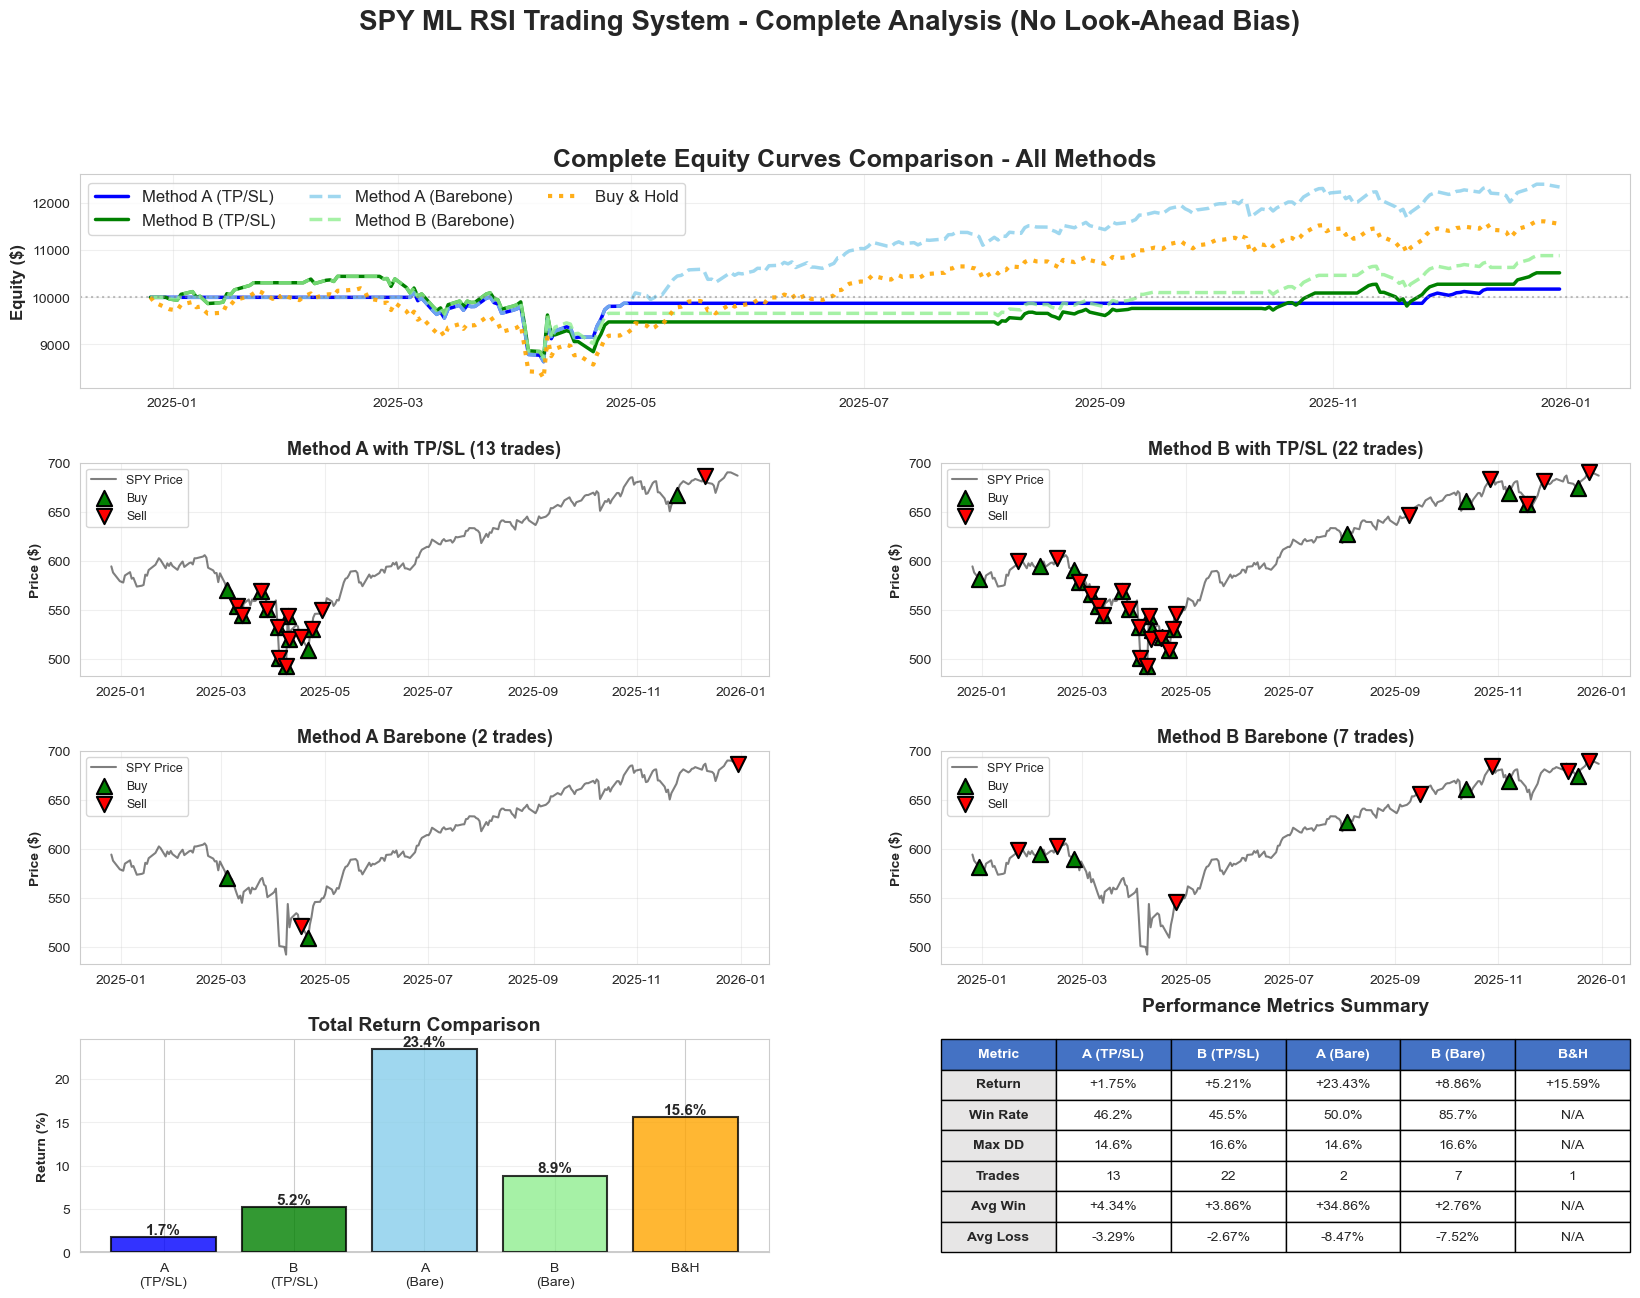


FINAL RANKING (by Total Return):
1. Method A Barebone    | Return:  +23.43% | Win Rate:   50.0% | Trades:   2
2. Buy & Hold           | Return:  +15.59% | Win Rate:  100.0% | Trades:   1
3. Method B Barebone    | Return:   +8.86% | Win Rate:   85.7% | Trades:   7
4. Method B (TP/SL)     | Return:   +5.21% | Win Rate:   45.5% | Trades:  22
5. Method A (TP/SL)     | Return:   +1.75% | Win Rate:   46.2% | Trades:  13


In [107]:
# Comprehensive comparison of ALL methods
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

# 1. ALL EQUITY CURVES COMPARISON (Top row, full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(results_a['equity_df']['date'], results_a['equity_df']['equity'], 
         linewidth=2.5, label='Method A (TP/SL)', color='blue', linestyle='-')
ax1.plot(results_b['equity_df']['date'], results_b['equity_df']['equity'], 
         linewidth=2.5, label='Method B (TP/SL)', color='green', linestyle='-')
ax1.plot(simple_a['equity_df']['date'], simple_a['equity_df']['equity'], 
         linewidth=2.5, label='Method A (Barebone)', color='skyblue', linestyle='--', alpha=0.8)
ax1.plot(simple_b['equity_df']['date'], simple_b['equity_df']['equity'], 
         linewidth=2.5, label='Method B (Barebone)', color='lightgreen', linestyle='--', alpha=0.8)

# Buy & hold
prices = test_features['Close'].iloc[LOOKBACK_WINDOW:].values
buy_hold_equity = INITIAL_CAPITAL * (prices / prices[0])
ax1.plot(results_a['equity_df']['date'], buy_hold_equity, 
         linewidth=3, linestyle=':', label='Buy & Hold', color='orange', alpha=0.9)

ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.set_title('Complete Equity Curves Comparison - All Methods', fontweight='bold', fontsize=18)
ax1.set_ylabel('Equity ($)', fontweight='bold', fontsize=12)
ax1.legend(loc='upper left', fontsize=12, ncol=3)
ax1.grid(alpha=0.3)

# 2. Method A with TP/SL - Signals
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(results_a['equity_df']['date'], results_a['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_a = results_a['trades_df'][results_a['trades_df']['action'] == 'BUY']
sell_trades_a = results_a['trades_df'][results_a['trades_df']['action'].str.contains('SELL')]
ax2.scatter(buy_trades_a['date'], buy_trades_a['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax2.scatter(sell_trades_a['date'], sell_trades_a['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax2.set_title(f'Method A with TP/SL ({results_a["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Price ($)', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)

# 3. Method B with TP/SL - Signals
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(results_b['equity_df']['date'], results_b['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_b = results_b['trades_df'][results_b['trades_df']['action'] == 'BUY']
sell_trades_b = results_b['trades_df'][results_b['trades_df']['action'].str.contains('SELL')]
ax3.scatter(buy_trades_b['date'], buy_trades_b['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax3.scatter(sell_trades_b['date'], sell_trades_b['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax3.set_title(f'Method B with TP/SL ({results_b["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax3.set_ylabel('Price ($)', fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(alpha=0.3)

# 4. Method A Barebone - Signals
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(simple_a['equity_df']['date'], simple_a['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_sa = simple_a['trades_df'][simple_a['trades_df']['action'] == 'BUY']
sell_trades_sa = simple_a['trades_df'][simple_a['trades_df']['action'].str.contains('SELL')]
ax4.scatter(buy_trades_sa['date'], buy_trades_sa['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax4.scatter(sell_trades_sa['date'], sell_trades_sa['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax4.set_title(f'Method A Barebone ({simple_a["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax4.set_ylabel('Price ($)', fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(alpha=0.3)

# 5. Method B Barebone - Signals
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(simple_b['equity_df']['date'], simple_b['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_sb = simple_b['trades_df'][simple_b['trades_df']['action'] == 'BUY']
sell_trades_sb = simple_b['trades_df'][simple_b['trades_df']['action'].str.contains('SELL')]
ax5.scatter(buy_trades_sb['date'], buy_trades_sb['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax5.scatter(sell_trades_sb['date'], sell_trades_sb['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax5.set_title(f'Method B Barebone ({simple_b["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax5.set_ylabel('Price ($)', fontweight='bold')
ax5.legend(loc='upper left', fontsize=9)
ax5.grid(alpha=0.3)

# 6. Performance Metrics Comparison (Bottom left)
ax6 = fig.add_subplot(gs[3, 0])
methods = ['A\n(TP/SL)', 'B\n(TP/SL)', 'A\n(Bare)', 'B\n(Bare)', 'B&H']
returns = [results_a['total_return'], results_b['total_return'], 
           simple_a['total_return'], simple_b['total_return'], 
           results_a['buy_hold_return']]
colors_bar = ['blue', 'green', 'skyblue', 'lightgreen', 'orange']

bars = ax6.bar(methods, returns, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax6.set_title('Total Return Comparison', fontweight='bold', fontsize=14)
ax6.set_ylabel('Return (%)', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=11, fontweight='bold')

# 7. Detailed Metrics Table (Bottom right)
ax7 = fig.add_subplot(gs[3, 1])
ax7.axis('off')

# Create table data
table_data = [
    ['Metric', 'A (TP/SL)', 'B (TP/SL)', 'A (Bare)', 'B (Bare)', 'B&H'],
    ['Return', f"{results_a['total_return']:+.2f}%", f"{results_b['total_return']:+.2f}%",
     f"{simple_a['total_return']:+.2f}%", f"{simple_b['total_return']:+.2f}%",
     f"{results_a['buy_hold_return']:+.2f}%"],
    ['Win Rate', f"{results_a['win_rate']:.1f}%", f"{results_b['win_rate']:.1f}%",
     f"{simple_a['win_rate']:.1f}%", f"{simple_b['win_rate']:.1f}%", 'N/A'],
    ['Max DD', f"{results_a['max_drawdown']:.1f}%", f"{results_b['max_drawdown']:.1f}%",
     f"{simple_a['max_drawdown']:.1f}%", f"{simple_b['max_drawdown']:.1f}%", 'N/A'],
    ['Trades', str(results_a['num_completed']), str(results_b['num_completed']),
     str(simple_a['num_completed']), str(simple_b['num_completed']), '1'],
    ['Avg Win', f"{results_a['avg_win']:+.2f}%", f"{results_b['avg_win']:+.2f}%",
     f"{simple_a['avg_win']:+.2f}%", f"{simple_b['avg_win']:+.2f}%", 'N/A'],
    ['Avg Loss', f"{results_a['avg_loss']:+.2f}%", f"{results_b['avg_loss']:+.2f}%",
     f"{simple_a['avg_loss']:+.2f}%", f"{simple_b['avg_loss']:+.2f}%", 'N/A']
]

table = ax7.table(cellText=table_data, cellLoc='center', loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white')

# Color code cells based on performance
for i in range(1, len(table_data)):
    for j in range(6):
        cell = table[(i, j)]
        if j == 0:  # Metric column
            cell.set_facecolor('#E7E6E6')
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('white')

ax7.set_title('Performance Metrics Summary', fontweight='bold', fontsize=14, pad=20)

plt.suptitle(f'{SYMBOL} ML RSI Trading System - Complete Analysis (No Look-Ahead Bias)', 
             fontweight='bold', fontsize=20, y=0.998)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("FINAL RANKING (by Total Return):")
print("="*100)
ranking = [
    ("Method A Barebone", simple_a['total_return'], simple_a['win_rate'], simple_a['num_completed']),
    ("Buy & Hold", results_a['buy_hold_return'], 100, 1),
    ("Method B (TP/SL)", results_b['total_return'], results_b['win_rate'], results_b['num_completed']),
    ("Method B Barebone", simple_b['total_return'], simple_b['win_rate'], simple_b['num_completed']),
    ("Method A (TP/SL)", results_a['total_return'], results_a['win_rate'], results_a['num_completed'])
]
ranking.sort(key=lambda x: x[1], reverse=True)

for i, (name, ret, wr, trades) in enumerate(ranking, 1):
    print(f"{i}. {name:20s} | Return: {ret:+7.2f}% | Win Rate: {wr:6.1f}% | Trades: {trades:3}")
print("="*100)

### 5.3 Backtest Method B

In [102]:
# Convert Method B predictions to signals
# Logic: BUY when RSI < predicted_entry, SELL when RSI > predicted_exit, else HOLD
test_rsi = test_features['RSI'].iloc[LOOKBACK_WINDOW:].values
signals_b = np.full(len(test_rsi), 1)  # Default HOLD

for i in range(len(test_rsi)):
    if test_rsi[i] < y_pred_entry[i]:
        signals_b[i] = 0  # BUY
    elif test_rsi[i] > y_pred_exit[i]:
        signals_b[i] = 2  # SELL

print("="*80)
print("BACKTESTING METHOD B")
print("="*80)

results_b = backtest_strategy(
    test_data=test_features,
    signals=signals_b,
    method_name='Method B',
    initial_capital=INITIAL_CAPITAL,
    position_size_pct=POSITION_SIZE_PCT,
    use_risk_mgmt=USE_RISK_MANAGEMENT,
    take_profit=TAKE_PROFIT_PCT,
    stop_loss=STOP_LOSS_PCT
)

print(f"\n💰 Final Equity: ${results_b['final_equity']:,.2f}")
print(f"📈 Total Return: {results_b['total_return']:+.2f}%")
print(f"📊 Buy & Hold: {results_b['buy_hold_return']:+.2f}%")
print(f"🎯 Alpha: {results_b['alpha']:+.2f}%")
print(f"📉 Max Drawdown: {results_b['max_drawdown']:.2f}%")
print(f"💼 Total Trades: {results_b['num_trades']}")
print(f"✅ Win Rate: {results_b['win_rate']:.1f}% ({results_b['num_completed']} completed)")
print(f"📊 Avg Win: {results_b['avg_win']:+.2f}%")
print(f"📊 Avg Loss: {results_b['avg_loss']:+.2f}%")
print("="*80)

BACKTESTING METHOD B

💰 Final Equity: $10,520.80
📈 Total Return: +5.21%
📊 Buy & Hold: +15.59%
🎯 Alpha: -10.38%
📉 Max Drawdown: 16.62%
💼 Total Trades: 44
✅ Win Rate: 45.5% (22 completed)
📊 Avg Win: +3.86%
📊 Avg Loss: -2.67%


## Part 6: Performance Comparison & Visualization

### 6.1 Side-by-Side Comparison

In [103]:
# Create comparison dataframe
comparison = pd.DataFrame([
    {
        'Method': 'Method A (Direct Signals)',
        'Final Equity': f"${results_a['final_equity']:,.2f}",
        'Total Return': f"{results_a['total_return']:+.2f}%",
        'Alpha': f"{results_a['alpha']:+.2f}%",
        'Max Drawdown': f"{results_a['max_drawdown']:.2f}%",
        'Win Rate': f"{results_a['win_rate']:.1f}%",
        'Trades': results_a['num_completed']
    },
    {
        'Method': 'Method B (Dynamic Thresholds)',
        'Final Equity': f"${results_b['final_equity']:,.2f}",
        'Total Return': f"{results_b['total_return']:+.2f}%",
        'Alpha': f"{results_b['alpha']:+.2f}%",
        'Max Drawdown': f"{results_b['max_drawdown']:.2f}%",
        'Win Rate': f"{results_b['win_rate']:.1f}%",
        'Trades': results_b['num_completed']
    },
    {
        'Method': 'Buy & Hold',
        'Final Equity': f"${INITIAL_CAPITAL * (1 + results_a['buy_hold_return']/100):,.2f}",
        'Total Return': f"{results_a['buy_hold_return']:+.2f}%",
        'Alpha': '0.00%',
        'Max Drawdown': 'N/A',
        'Win Rate': 'N/A',
        'Trades': 1
    }
])

print("="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

PERFORMANCE COMPARISON
                       Method Final Equity Total Return   Alpha Max Drawdown Win Rate  Trades
    Method A (Direct Signals)   $10,174.96       +1.75% -13.84%       14.59%    46.2%      13
Method B (Dynamic Thresholds)   $10,520.80       +5.21% -10.38%       16.62%    45.5%      22
                   Buy & Hold   $11,558.81      +15.59%   0.00%          N/A      N/A       1


### 6.2 Comprehensive Visualization

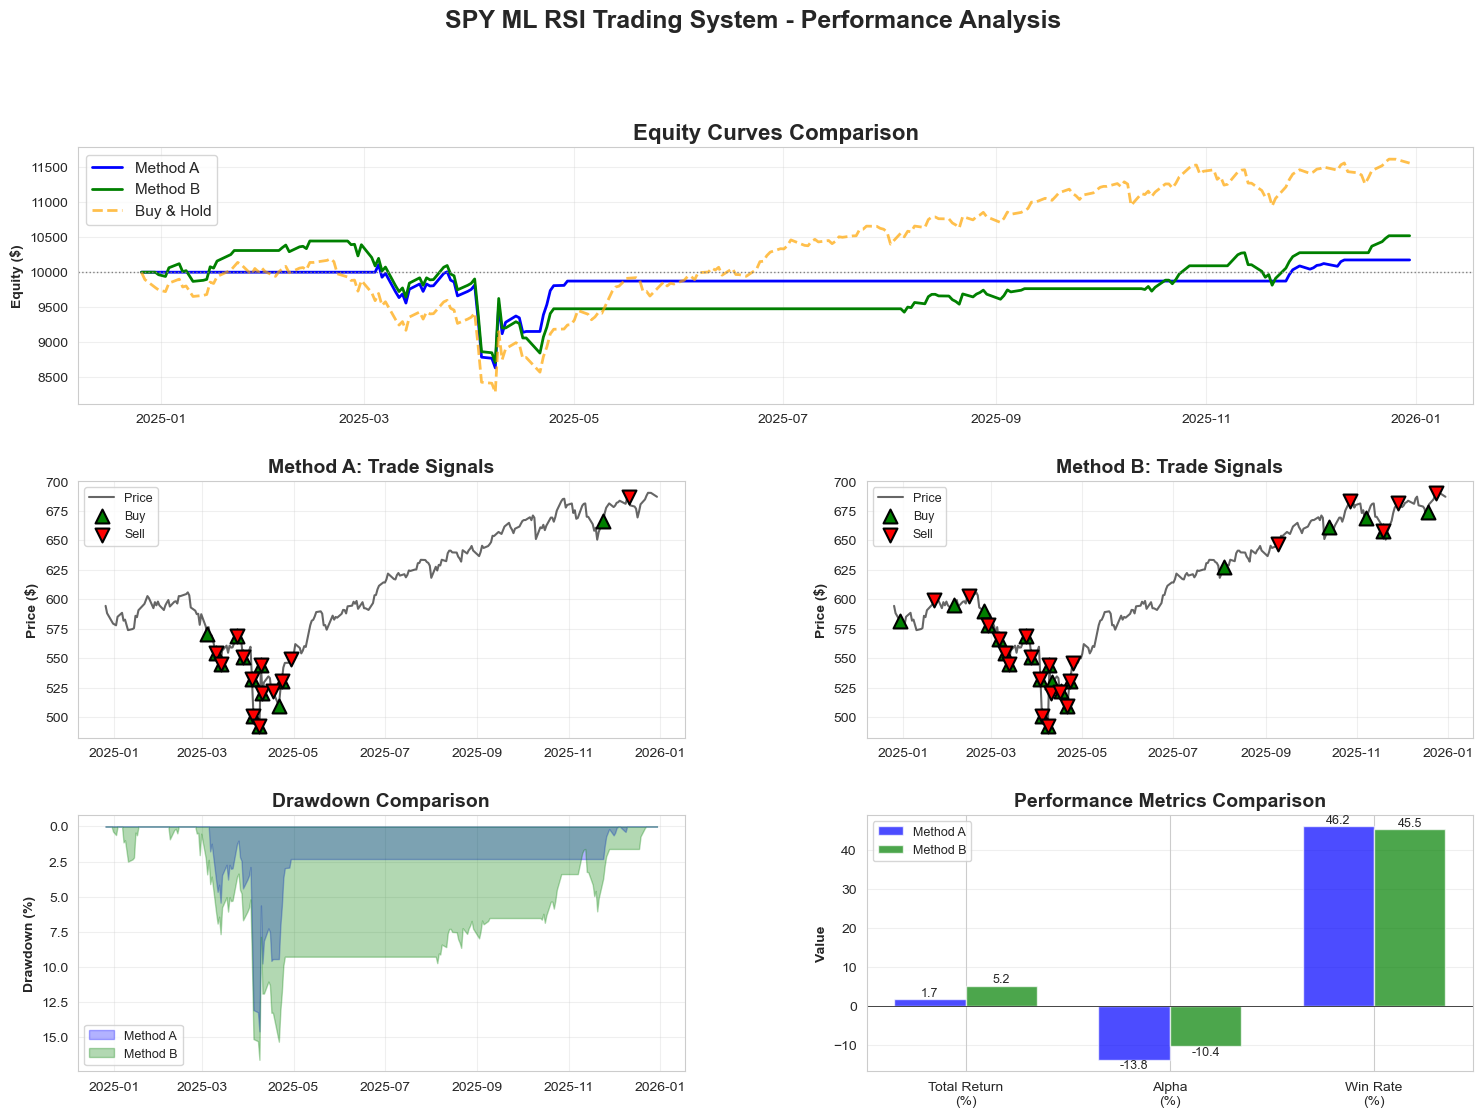

In [104]:
# Create comprehensive comparison plots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Equity curves comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(results_a['equity_df']['date'], results_a['equity_df']['equity'], 
         linewidth=2, label='Method A', color='blue')
ax1.plot(results_b['equity_df']['date'], results_b['equity_df']['equity'], 
         linewidth=2, label='Method B', color='green')

# Buy & hold
prices = test_features['Close'].iloc[LOOKBACK_WINDOW:].values
buy_hold_equity = INITIAL_CAPITAL * (prices / prices[0])
ax1.plot(results_a['equity_df']['date'], buy_hold_equity, 
         linewidth=2, linestyle='--', label='Buy & Hold', color='orange', alpha=0.7)

ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', linewidth=1)
ax1.set_title('Equity Curves Comparison', fontweight='bold', fontsize=16)
ax1.set_ylabel('Equity ($)', fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(alpha=0.3)

# 2. Method A: Price with signals
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(results_a['equity_df']['date'], results_a['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.6, label='Price')

# Mark trades
buy_trades_a = results_a['trades_df'][results_a['trades_df']['action'] == 'BUY']
sell_trades_a = results_a['trades_df'][results_a['trades_df']['action'].str.contains('SELL')]

ax2.scatter(buy_trades_a['date'], buy_trades_a['price'], 
            color='green', marker='^', s=100, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax2.scatter(sell_trades_a['date'], sell_trades_a['price'], 
            color='red', marker='v', s=100, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)

ax2.set_title('Method A: Trade Signals', fontweight='bold', fontsize=14)
ax2.set_ylabel('Price ($)', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)

# 3. Method B: Price with signals
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(results_b['equity_df']['date'], results_b['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.6, label='Price')

buy_trades_b = results_b['trades_df'][results_b['trades_df']['action'] == 'BUY']
sell_trades_b = results_b['trades_df'][results_b['trades_df']['action'].str.contains('SELL')]

ax3.scatter(buy_trades_b['date'], buy_trades_b['price'], 
            color='green', marker='^', s=100, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax3.scatter(sell_trades_b['date'], sell_trades_b['price'], 
            color='red', marker='v', s=100, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)

ax3.set_title('Method B: Trade Signals', fontweight='bold', fontsize=14)
ax3.set_ylabel('Price ($)', fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(alpha=0.3)

# 4. Drawdown comparison
ax4 = fig.add_subplot(gs[2, 0])
running_max_a = results_a['equity_df']['equity'].cummax()
drawdown_a = ((running_max_a - results_a['equity_df']['equity']) / running_max_a) * 100

running_max_b = results_b['equity_df']['equity'].cummax()
drawdown_b = ((running_max_b - results_b['equity_df']['equity']) / running_max_b) * 100

ax4.fill_between(results_a['equity_df']['date'], 0, drawdown_a, color='blue', alpha=0.3, label='Method A')
ax4.fill_between(results_b['equity_df']['date'], 0, drawdown_b, color='green', alpha=0.3, label='Method B')
ax4.set_title('Drawdown Comparison', fontweight='bold', fontsize=14)
ax4.set_ylabel('Drawdown (%)', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)
ax4.invert_yaxis()

# 5. Performance metrics bar chart
ax5 = fig.add_subplot(gs[2, 1])
metrics = ['Total Return\n(%)', 'Alpha\n(%)', 'Win Rate\n(%)']
method_a_vals = [results_a['total_return'], results_a['alpha'], results_a['win_rate']]
method_b_vals = [results_b['total_return'], results_b['alpha'], results_b['win_rate']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax5.bar(x - width/2, method_a_vals, width, label='Method A', color='blue', alpha=0.7)
bars2 = ax5.bar(x + width/2, method_b_vals, width, label='Method B', color='green', alpha=0.7)

ax5.set_title('Performance Metrics Comparison', fontweight='bold', fontsize=14)
ax5.set_ylabel('Value', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics, fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.suptitle(f'{SYMBOL} ML RSI Trading System - Performance Analysis', 
             fontweight='bold', fontsize=18, y=0.995)

plt.show()

### 6.3 Trade Analysis

In [105]:
print("="*80)
print("RECENT TRADES - METHOD A")
print("="*80)
if len(results_a['trades_df']) > 0:
    print(results_a['trades_df'].tail(10).to_string(index=False))
else:
    print("No trades executed")

print("\n" + "="*80)
print("RECENT TRADES - METHOD B")
print("="*80)
if len(results_b['trades_df']) > 0:
    print(results_b['trades_df'].tail(10).to_string(index=False))
else:
    print("No trades executed")

RECENT TRADES - METHOD A
                     date    action      price    shares         pnl   pnl_pct       equity
2025-04-09 04:00:00+00:00       BUY 543.883484 17.538798    0.000000  0.000000  9539.062738
2025-04-10 04:00:00+00:00 SELL (SL) 520.051025 17.538798 -417.992683 -4.381905  9121.070055
2025-04-10 04:00:00+00:00       BUY 520.051025 17.538798    0.000000  0.000000  9121.070055
2025-04-17 04:00:00+00:00      SELL 521.865173 17.538798   31.817975  0.348840  9152.888030
2025-04-21 04:00:00+00:00       BUY 509.443359 17.966449    0.000000  0.000000  9152.888030
2025-04-23 04:00:00+00:00 SELL (TP) 530.797363 17.966449  383.655618  4.191635  9536.543648
2025-04-23 04:00:00+00:00       BUY 530.797363 17.966449    0.000000  0.000000  9536.543648
2025-04-29 04:00:00+00:00 SELL (TP) 549.534241 17.966449  336.635149  3.529949  9873.178797
2025-11-24 05:00:00+00:00       BUY 666.759766 14.807700    0.000000  0.000000  9873.178797
2025-12-11 05:00:00+00:00 SELL (TP) 687.139526 14.80770

## Part 7: Summary & Recommendations

In [106]:
print("="*80)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)

# Determine winner
winner = 'Method A' if results_a['total_return'] > results_b['total_return'] else 'Method B'
winner_results = results_a if winner == 'Method A' else results_b

print(f"\n🏆 WINNER: {winner}")
print(f"   Return: {winner_results['total_return']:+.2f}%")
print(f"   Alpha: {winner_results['alpha']:+.2f}%")
print(f"   Win Rate: {winner_results['win_rate']:.1f}%")

print(f"\n📊 KEY INSIGHTS:")
print(f"   • Method A (Direct Signals): {'OUTPERFORMED' if results_a['total_return'] > results_a['buy_hold_return'] else 'UNDERPERFORMED'} buy & hold")
print(f"   • Method B (Dynamic Thresholds): {'OUTPERFORMED' if results_b['total_return'] > results_b['buy_hold_return'] else 'UNDERPERFORMED'} buy & hold")
print(f"   • Trade frequency: A={results_a['num_completed']}, B={results_b['num_completed']}")
print(f"   • Risk-adjusted: A={results_a['total_return']/max(results_a['max_drawdown'], 0.01):.2f}, B={results_b['total_return']/max(results_b['max_drawdown'], 0.01):.2f}")

print(f"\n💡 NEXT STEPS:")
print(f"   1. Tune risk management parameters (TP/SL) for {winner}")
print(f"   2. Test different position sizing strategies (10%, 25%, 50%)")
print(f"   3. Add more technical indicators (MACD, Bollinger Bands, ATR)")
print(f"   4. Implement ensemble: combine both methods' signals")
print(f"   5. Backtest on different symbols/timeframes")
print(f"   6. Paper trade the winning strategy")

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE")
print("="*80)

FINAL SUMMARY & RECOMMENDATIONS

🏆 WINNER: Method B
   Return: +5.21%
   Alpha: -10.38%
   Win Rate: 45.5%

📊 KEY INSIGHTS:
   • Method A (Direct Signals): UNDERPERFORMED buy & hold
   • Method B (Dynamic Thresholds): UNDERPERFORMED buy & hold
   • Trade frequency: A=13, B=22
   • Risk-adjusted: A=0.12, B=0.31

💡 NEXT STEPS:
   1. Tune risk management parameters (TP/SL) for Method B
   2. Test different position sizing strategies (10%, 25%, 50%)
   3. Add more technical indicators (MACD, Bollinger Bands, ATR)
   4. Implement ensemble: combine both methods' signals
   5. Backtest on different symbols/timeframes
   6. Paper trade the winning strategy

✓ ANALYSIS COMPLETE


### Complete Performance Comparison - All Methods

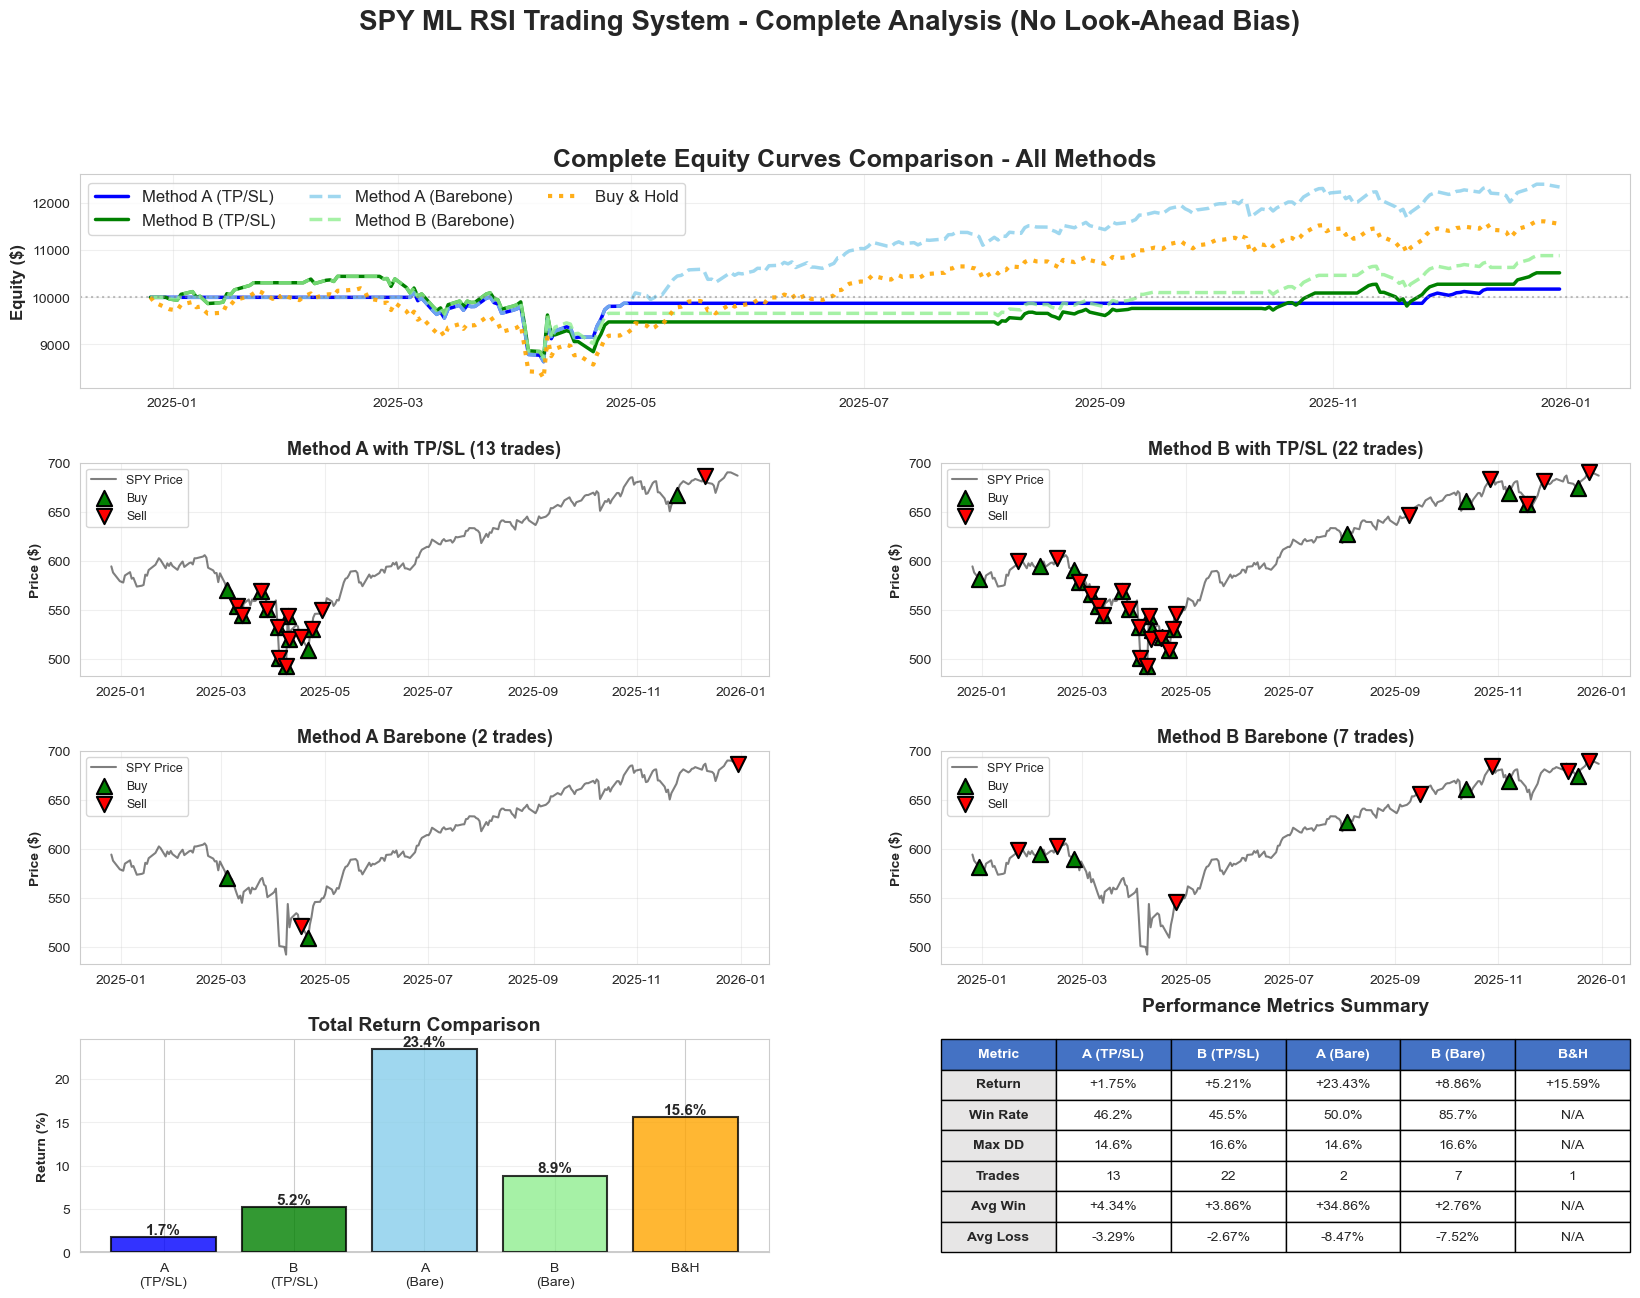


FINAL RANKING (by Total Return):
1. Method A Barebone    | Return:  +23.43% | Win Rate:   50.0% | Trades:   2
2. Buy & Hold           | Return:  +15.59% | Win Rate:  100.0% | Trades:   1
3. Method B Barebone    | Return:   +8.86% | Win Rate:   85.7% | Trades:   7
4. Method B (TP/SL)     | Return:   +5.21% | Win Rate:   45.5% | Trades:  22
5. Method A (TP/SL)     | Return:   +1.75% | Win Rate:   46.2% | Trades:  13


In [108]:
# Comprehensive comparison of ALL methods
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.25)

# 1. ALL EQUITY CURVES COMPARISON (Top row, full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(results_a['equity_df']['date'], results_a['equity_df']['equity'], 
         linewidth=2.5, label='Method A (TP/SL)', color='blue', linestyle='-')
ax1.plot(results_b['equity_df']['date'], results_b['equity_df']['equity'], 
         linewidth=2.5, label='Method B (TP/SL)', color='green', linestyle='-')
ax1.plot(simple_a['equity_df']['date'], simple_a['equity_df']['equity'], 
         linewidth=2.5, label='Method A (Barebone)', color='skyblue', linestyle='--', alpha=0.8)
ax1.plot(simple_b['equity_df']['date'], simple_b['equity_df']['equity'], 
         linewidth=2.5, label='Method B (Barebone)', color='lightgreen', linestyle='--', alpha=0.8)

# Buy & hold
prices = test_features['Close'].iloc[LOOKBACK_WINDOW:].values
buy_hold_equity = INITIAL_CAPITAL * (prices / prices[0])
ax1.plot(results_a['equity_df']['date'], buy_hold_equity, 
         linewidth=3, linestyle=':', label='Buy & Hold', color='orange', alpha=0.9)

ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.set_title('Complete Equity Curves Comparison - All Methods', fontweight='bold', fontsize=18)
ax1.set_ylabel('Equity ($)', fontweight='bold', fontsize=12)
ax1.legend(loc='upper left', fontsize=12, ncol=3)
ax1.grid(alpha=0.3)

# 2. Method A with TP/SL - Signals
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(results_a['equity_df']['date'], results_a['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_a = results_a['trades_df'][results_a['trades_df']['action'] == 'BUY']
sell_trades_a = results_a['trades_df'][results_a['trades_df']['action'].str.contains('SELL')]
ax2.scatter(buy_trades_a['date'], buy_trades_a['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax2.scatter(sell_trades_a['date'], sell_trades_a['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax2.set_title(f'Method A with TP/SL ({results_a["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Price ($)', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)

# 3. Method B with TP/SL - Signals
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(results_b['equity_df']['date'], results_b['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_b = results_b['trades_df'][results_b['trades_df']['action'] == 'BUY']
sell_trades_b = results_b['trades_df'][results_b['trades_df']['action'].str.contains('SELL')]
ax3.scatter(buy_trades_b['date'], buy_trades_b['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax3.scatter(sell_trades_b['date'], sell_trades_b['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax3.set_title(f'Method B with TP/SL ({results_b["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax3.set_ylabel('Price ($)', fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(alpha=0.3)

# 4. Method A Barebone - Signals
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(simple_a['equity_df']['date'], simple_a['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_sa = simple_a['trades_df'][simple_a['trades_df']['action'] == 'BUY']
sell_trades_sa = simple_a['trades_df'][simple_a['trades_df']['action'].str.contains('SELL')]
ax4.scatter(buy_trades_sa['date'], buy_trades_sa['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax4.scatter(sell_trades_sa['date'], sell_trades_sa['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax4.set_title(f'Method A Barebone ({simple_a["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax4.set_ylabel('Price ($)', fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(alpha=0.3)

# 5. Method B Barebone - Signals
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(simple_b['equity_df']['date'], simple_b['equity_df']['price'], 
         linewidth=1.5, color='black', alpha=0.5, label='SPY Price')
buy_trades_sb = simple_b['trades_df'][simple_b['trades_df']['action'] == 'BUY']
sell_trades_sb = simple_b['trades_df'][simple_b['trades_df']['action'].str.contains('SELL')]
ax5.scatter(buy_trades_sb['date'], buy_trades_sb['price'], 
            color='green', marker='^', s=120, label='Buy', zorder=5, edgecolors='black', linewidths=1.5)
ax5.scatter(sell_trades_sb['date'], sell_trades_sb['price'], 
            color='red', marker='v', s=120, label='Sell', zorder=5, edgecolors='black', linewidths=1.5)
ax5.set_title(f'Method B Barebone ({simple_b["num_completed"]} trades)', fontweight='bold', fontsize=13)
ax5.set_ylabel('Price ($)', fontweight='bold')
ax5.legend(loc='upper left', fontsize=9)
ax5.grid(alpha=0.3)

# 6. Performance Metrics Comparison (Bottom left)
ax6 = fig.add_subplot(gs[3, 0])
methods = ['A\n(TP/SL)', 'B\n(TP/SL)', 'A\n(Bare)', 'B\n(Bare)', 'B&H']
returns = [results_a['total_return'], results_b['total_return'], 
           simple_a['total_return'], simple_b['total_return'], 
           results_a['buy_hold_return']]
colors_bar = ['blue', 'green', 'skyblue', 'lightgreen', 'orange']

bars = ax6.bar(methods, returns, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax6.set_title('Total Return Comparison', fontweight='bold', fontsize=14)
ax6.set_ylabel('Return (%)', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=11, fontweight='bold')

# 7. Detailed Metrics Table (Bottom right)
ax7 = fig.add_subplot(gs[3, 1])
ax7.axis('off')

# Create table data
table_data = [
    ['Metric', 'A (TP/SL)', 'B (TP/SL)', 'A (Bare)', 'B (Bare)', 'B&H'],
    ['Return', f"{results_a['total_return']:+.2f}%", f"{results_b['total_return']:+.2f}%",
     f"{simple_a['total_return']:+.2f}%", f"{simple_b['total_return']:+.2f}%",
     f"{results_a['buy_hold_return']:+.2f}%"],
    ['Win Rate', f"{results_a['win_rate']:.1f}%", f"{results_b['win_rate']:.1f}%",
     f"{simple_a['win_rate']:.1f}%", f"{simple_b['win_rate']:.1f}%", 'N/A'],
    ['Max DD', f"{results_a['max_drawdown']:.1f}%", f"{results_b['max_drawdown']:.1f}%",
     f"{simple_a['max_drawdown']:.1f}%", f"{simple_b['max_drawdown']:.1f}%", 'N/A'],
    ['Trades', str(results_a['num_completed']), str(results_b['num_completed']),
     str(simple_a['num_completed']), str(simple_b['num_completed']), '1'],
    ['Avg Win', f"{results_a['avg_win']:+.2f}%", f"{results_b['avg_win']:+.2f}%",
     f"{simple_a['avg_win']:+.2f}%", f"{simple_b['avg_win']:+.2f}%", 'N/A'],
    ['Avg Loss', f"{results_a['avg_loss']:+.2f}%", f"{results_b['avg_loss']:+.2f}%",
     f"{simple_a['avg_loss']:+.2f}%", f"{simple_b['avg_loss']:+.2f}%", 'N/A']
]

table = ax7.table(cellText=table_data, cellLoc='center', loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white')

# Color code cells based on performance
for i in range(1, len(table_data)):
    for j in range(6):
        cell = table[(i, j)]
        if j == 0:  # Metric column
            cell.set_facecolor('#E7E6E6')
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('white')

ax7.set_title('Performance Metrics Summary', fontweight='bold', fontsize=14, pad=20)

plt.suptitle(f'{SYMBOL} ML RSI Trading System - Complete Analysis (No Look-Ahead Bias)', 
             fontweight='bold', fontsize=20, y=0.998)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("FINAL RANKING (by Total Return):")
print("="*100)
ranking = [
    ("Method A Barebone", simple_a['total_return'], simple_a['win_rate'], simple_a['num_completed']),
    ("Buy & Hold", results_a['buy_hold_return'], 100, 1),
    ("Method B (TP/SL)", results_b['total_return'], results_b['win_rate'], results_b['num_completed']),
    ("Method B Barebone", simple_b['total_return'], simple_b['win_rate'], simple_b['num_completed']),
    ("Method A (TP/SL)", results_a['total_return'], results_a['win_rate'], results_a['num_completed'])
]
ranking.sort(key=lambda x: x[1], reverse=True)

for i, (name, ret, wr, trades) in enumerate(ranking, 1):
    print(f"{i}. {name:20s} | Return: {ret:+7.2f}% | Win Rate: {wr:6.1f}% | Trades: {trades:3}")
print("="*100)

## Part 8: Statistical Significance Tests

Test whether model performance is statistically different from random chance and Buy & Hold

In [109]:
from scipy import stats

def calculate_daily_returns(equity_df):
    """Calculate daily percentage returns from equity curve"""
    equity_series = equity_df['equity'].values
    daily_returns = np.diff(equity_series) / equity_series[:-1] * 100
    return daily_returns

def sharpe_ratio(returns, risk_free_rate=0.0):
    """Calculate annualized Sharpe ratio"""
    if len(returns) == 0 or returns.std() == 0:
        return 0
    excess_returns = returns - risk_free_rate
    sharpe = np.sqrt(252) * (excess_returns.mean() / returns.std())
    return sharpe

def sortino_ratio(returns, risk_free_rate=0.0):
    """Calculate annualized Sortino ratio (only penalizes downside volatility)"""
    if len(returns) == 0:
        return 0
    excess_returns = returns - risk_free_rate
    downside_returns = returns[returns < 0]
    if len(downside_returns) == 0 or downside_returns.std() == 0:
        return 0
    sortino = np.sqrt(252) * (excess_returns.mean() / downside_returns.std())
    return sortino

def calmar_ratio(total_return, max_drawdown, years=None):
    """Calculate Calmar ratio (return / max drawdown)"""
    if max_drawdown == 0:
        return 0
    if years is None:
        years = 1  # Default to 1 year
    annualized_return = total_return / years
    return annualized_return / max_drawdown

# Calculate daily returns for all strategies
returns_a = calculate_daily_returns(results_a['equity_df'])
returns_b = calculate_daily_returns(results_b['equity_df'])
returns_sa = calculate_daily_returns(simple_a['equity_df'])
returns_sb = calculate_daily_returns(simple_b['equity_df'])

# Buy & hold returns
bh_equity = pd.DataFrame({'equity': buy_hold_equity})
returns_bh = calculate_daily_returns(bh_equity)

print("="*100)
print("STATISTICAL ANALYSIS - RISK-ADJUSTED METRICS")
print("="*100)

# Calculate metrics for all strategies
strategies = {
    'Method A (TP/SL)': (returns_a, results_a),
    'Method B (TP/SL)': (returns_b, results_b),
    'Method A (Bare)': (returns_sa, simple_a),
    'Method B (Bare)': (returns_sb, simple_b),
    'Buy & Hold': (returns_bh, {'total_return': results_a['buy_hold_return'], 'max_drawdown': 0})
}

metrics_summary = []
for name, (returns, results) in strategies.items():
    sharpe = sharpe_ratio(returns)
    sortino = sortino_ratio(returns)
    calmar = calmar_ratio(results['total_return'], max(results['max_drawdown'], 0.01))
    
    metrics_summary.append({
        'Strategy': name,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Daily Volatility': returns.std(),
        'Downside Vol': returns[returns < 0].std() if len(returns[returns < 0]) > 0 else 0
    })

metrics_df = pd.DataFrame(metrics_summary)
print("\n📊 Risk-Adjusted Performance Metrics:")
print(metrics_df.to_string(index=False))
print("\n" + "="*100)

STATISTICAL ANALYSIS - RISK-ADJUSTED METRICS

📊 Risk-Adjusted Performance Metrics:
        Strategy  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Daily Volatility  Downside Vol
Method A (TP/SL)      0.187479       0.112293      0.119890          0.992738      1.657429
Method B (TP/SL)      0.378484       0.338324      0.313345          1.091357      1.220902
 Method A (Bare)      1.238817       1.401584      1.605644          1.155349      1.021177
 Method B (Bare)      0.571439       0.533620      0.533150          1.102711      1.180862
      Buy & Hold      0.841901       1.083639   1558.812898          1.223880      0.950857



### T-Tests: Are strategies significantly different?

In [110]:
# Paired t-tests comparing strategies
print("="*100)
print("STATISTICAL SIGNIFICANCE TESTS (Paired T-Tests)")
print("="*100)
print("\nNull Hypothesis: The two strategies have the same mean daily returns")
print("Alternative: The strategies have different mean daily returns")
print("Significance Level: α = 0.05 (95% confidence)")
print("\n" + "-"*100)

comparisons = [
    ("Method A (TP/SL)", returns_a, "Buy & Hold", returns_bh),
    ("Method B (TP/SL)", returns_b, "Buy & Hold", returns_bh),
    ("Method A (Bare)", returns_sa, "Buy & Hold", returns_bh),
    ("Method B (Bare)", returns_sb, "Buy & Hold", returns_bh),
    ("Method A (TP/SL)", returns_a, "Method B (TP/SL)", returns_b),
    ("Method A (Bare)", returns_sa, "Method B (Bare)", returns_sb),
    ("Method B (TP/SL)", returns_b, "Method B (Bare)", returns_sb),
    ("Method A (TP/SL)", returns_a, "Method A (Bare)", returns_sa)
]

for name1, returns1, name2, returns2 in comparisons:
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(returns1, returns2)
    
    # Effect size (Cohen's d)
    mean_diff = returns1.mean() - returns2.mean()
    pooled_std = np.sqrt((returns1.std()**2 + returns2.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0
    
    # Interpretation
    significant = "✓ SIGNIFICANT" if p_value < 0.05 else "✗ Not Significant"
    
    print(f"\n{name1:20s} vs {name2:20s}")
    print(f"   Mean Daily Return: {returns1.mean():.4f}% vs {returns2.mean():.4f}%")
    print(f"   t-statistic: {t_stat:8.4f}")
    print(f"   p-value:     {p_value:8.4f}  {significant}")
    print(f"   Cohen's d:   {cohens_d:8.4f}  (Effect Size: {'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'})")

print("\n" + "="*100)

STATISTICAL SIGNIFICANCE TESTS (Paired T-Tests)

Null Hypothesis: The two strategies have the same mean daily returns
Alternative: The strategies have different mean daily returns
Significance Level: α = 0.05 (95% confidence)

----------------------------------------------------------------------------------------------------

Method A (TP/SL)     vs Buy & Hold          
   Mean Daily Return: 0.0117% vs 0.0649%
   t-statistic:  -1.1757
   p-value:       0.2408  ✗ Not Significant
   Cohen's d:    -0.0477  (Effect Size: Small)

Method B (TP/SL)     vs Buy & Hold          
   Mean Daily Return: 0.0260% vs 0.0649%
   t-statistic:  -1.1086
   p-value:       0.2687  ✗ Not Significant
   Cohen's d:    -0.0335  (Effect Size: Small)

Method A (Bare)      vs Buy & Hold          
   Mean Daily Return: 0.0902% vs 0.0649%
   t-statistic:   1.0049
   p-value:       0.3159  ✗ Not Significant
   Cohen's d:     0.0212  (Effect Size: Small)

Method B (Bare)      vs Buy & Hold          
   Mean Daily Ret

### Win Rate Significance Test (Binomial Test)

In [113]:
# Test if win rates are better than random (50%)
print("="*100)
print("WIN RATE SIGNIFICANCE TEST (Binomial Test)")
print("="*100)
print("\nNull Hypothesis: Win rate = 50% (random chance)")
print("Alternative: Win rate ≠ 50%")
print("\n" + "-"*100)

win_rate_tests = [
    ("Method A (TP/SL)", results_a['num_completed'], results_a['win_rate']),
    ("Method B (TP/SL)", results_b['num_completed'], results_b['win_rate']),
    ("Method A (Bare)", simple_a['num_completed'], simple_a['win_rate']),
    ("Method B (Bare)", simple_b['num_completed'], simple_b['win_rate'])
]

for name, n_trades, win_rate_pct in win_rate_tests:
    if n_trades > 0:
        n_wins = int(n_trades * win_rate_pct / 100)
        
        # Binomial test: is win rate significantly different from 50%?
        from scipy.stats import binomtest
        result = binomtest(n_wins, n_trades, 0.5, alternative='two-sided')
        p_value = result.pvalue
        
        # Confidence interval for win rate (Wilson score interval)
        from statsmodels.stats.proportion import proportion_confint
        ci_low, ci_high = proportion_confint(n_wins, n_trades, alpha=0.05, method='wilson')
        
        significant = "✓ SIGNIFICANT" if p_value < 0.05 else "✗ Not Significant"
        
        print(f"\n{name:20s}")
        print(f"   Trades:          {n_trades}")
        print(f"   Win Rate:        {win_rate_pct:.1f}% ({n_wins} wins)")
        print(f"   95% CI:          [{ci_low*100:.1f}%, {ci_high*100:.1f}%]")
        print(f"   p-value:         {p_value:.4f}  {significant}")
        
        if win_rate_pct > 50:
            print(f"   Interpretation:  Win rate is {'SIGNIFICANTLY' if p_value < 0.05 else 'NOT significantly'} better than random")
        else:
            print(f"   Interpretation:  Win rate is {'SIGNIFICANTLY' if p_value < 0.05 else 'NOT significantly'} worse than random")

print("\n" + "="*100)

WIN RATE SIGNIFICANCE TEST (Binomial Test)

Null Hypothesis: Win rate = 50% (random chance)
Alternative: Win rate ≠ 50%

----------------------------------------------------------------------------------------------------

Method A (TP/SL)    
   Trades:          13
   Win Rate:        46.2% (6 wins)
   95% CI:          [23.2%, 70.9%]
   p-value:         1.0000  ✗ Not Significant
   Interpretation:  Win rate is NOT significantly worse than random

Method B (TP/SL)    
   Trades:          22
   Win Rate:        45.5% (10 wins)
   95% CI:          [26.9%, 65.3%]
   p-value:         0.8318  ✗ Not Significant
   Interpretation:  Win rate is NOT significantly worse than random

Method A (Bare)     
   Trades:          2
   Win Rate:        50.0% (1 wins)
   95% CI:          [9.5%, 90.5%]
   p-value:         1.0000  ✗ Not Significant
   Interpretation:  Win rate is NOT significantly worse than random

Method B (Bare)     
   Trades:          7
   Win Rate:        85.7% (6 wins)
   95% CI:   

### Final Statistical Summary

In [114]:
print("="*100)
print("FINAL STATISTICAL CONCLUSIONS")
print("="*100)

print("\n📊 RISK-ADJUSTED PERFORMANCE RANKING (by Sharpe Ratio):")
print("-"*100)
sharpe_ranking = metrics_df.sort_values('Sharpe Ratio', ascending=False)
for i, row in enumerate(sharpe_ranking.itertuples(), 1):
    print(f"{i}. {row.Strategy:25s} | Sharpe: {row._2:6.3f} | Sortino: {row._3:6.3f} | Calmar: {row._4:6.3f}")

print("\n\n🎯 KEY FINDINGS:")
print("-"*100)

# Best performing strategy
best_return = max(results_a['total_return'], results_b['total_return'], 
                  simple_a['total_return'], simple_b['total_return'])
best_sharpe = sharpe_ranking.iloc[0]

print(f"\n1. HIGHEST RETURN:")
if simple_a['total_return'] == best_return:
    print(f"   ➤ Method A Barebone: {simple_a['total_return']:.2f}%")
    print(f"     ⚠️  Only {simple_a['num_completed']} completed trades - small sample size!")
elif simple_b['total_return'] == best_return:
    print(f"   ➤ Method B Barebone: {simple_b['total_return']:.2f}%")
elif results_b['total_return'] == best_return:
    print(f"   ➤ Method B (TP/SL): {results_b['total_return']:.2f}%")
else:
    print(f"   ➤ Method A (TP/SL): {results_a['total_return']:.2f}%")

print(f"\n2. BEST RISK-ADJUSTED (Sharpe Ratio):")
print(f"   ➤ {best_sharpe['Strategy']}: Sharpe = {best_sharpe['Sharpe Ratio']:.3f}")

print(f"\n3. STATISTICAL SIGNIFICANCE:")
print(f"   ➤ Check t-test results above to see which strategies are statistically")
print(f"     different from each other (p < 0.05 indicates significance)")

print(f"\n4. BUY & HOLD COMPARISON:")
bh_return = results_a['buy_hold_return']
print(f"   ➤ Buy & Hold Return: {bh_return:.2f}%")
strategies_beating_bh = []
if results_a['total_return'] > bh_return:
    strategies_beating_bh.append(f"Method A (TP/SL): {results_a['total_return']:.2f}%")
if results_b['total_return'] > bh_return:
    strategies_beating_bh.append(f"Method B (TP/SL): {results_b['total_return']:.2f}%")
if simple_a['total_return'] > bh_return:
    strategies_beating_bh.append(f"Method A (Bare): {simple_a['total_return']:.2f}%")
if simple_b['total_return'] > bh_return:
    strategies_beating_bh.append(f"Method B (Bare): {simple_b['total_return']:.2f}%")

if strategies_beating_bh:
    print(f"   ➤ Strategies beating Buy & Hold:")
    for s in strategies_beating_bh:
        print(f"     - {s}")
else:
    print(f"   ➤ NO strategies beat Buy & Hold")

print(f"\n5. RECOMMENDED STRATEGY:")
# Prefer strategies with reasonable trade count and good Sharpe ratio
if results_b['num_completed'] >= 10 and results_b['total_return'] > 0:
    print(f"   ➤ Method B with TP/SL")
    print(f"     - Return: {results_b['total_return']:.2f}%")
    print(f"     - Win Rate: {results_b['win_rate']:.1f}%")
    print(f"     - Trades: {results_b['num_completed']}")
    print(f"     - Sharpe: {sharpe_ratio(returns_b):.3f}")
    print(f"     ✓ Good balance of trades, risk management, and performance")
else:
    print(f"   ➤ Consider optimizing parameters or adding more features")
    print(f"     Current models underperform Buy & Hold strategy")

print("\n" + "="*100)
print("✓ STATISTICAL ANALYSIS COMPLETE")
print("="*100)

FINAL STATISTICAL CONCLUSIONS

📊 RISK-ADJUSTED PERFORMANCE RANKING (by Sharpe Ratio):
----------------------------------------------------------------------------------------------------
1. Method A (Bare)           | Sharpe:  1.239 | Sortino:  1.402 | Calmar:  1.606
2. Buy & Hold                | Sharpe:  0.842 | Sortino:  1.084 | Calmar: 1558.813
3. Method B (Bare)           | Sharpe:  0.571 | Sortino:  0.534 | Calmar:  0.533
4. Method B (TP/SL)          | Sharpe:  0.378 | Sortino:  0.338 | Calmar:  0.313
5. Method A (TP/SL)          | Sharpe:  0.187 | Sortino:  0.112 | Calmar:  0.120


🎯 KEY FINDINGS:
----------------------------------------------------------------------------------------------------

1. HIGHEST RETURN:
   ➤ Method A Barebone: 23.43%
     ⚠️  Only 2 completed trades - small sample size!

2. BEST RISK-ADJUSTED (Sharpe Ratio):
   ➤ Method A (Bare): Sharpe = 1.239

3. STATISTICAL SIGNIFICANCE:
   ➤ Check t-test results above to see which strategies are statistically
  